# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** Lina María Castro
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# 💳 **Inclusión financiera y pobreza: ¿el acceso al crédito formal está asociado con mejores condiciones de bienestar en los hogares rurales de Colombia?**

**Segunda entrega: importación, auditoría, unión, limpieza, creación de variables y análisis exploratorio (EDA)**

**Integrantes:** Isabella Ramirez Santamaria, Kevin Stiven Albarracin González, Julián Eduardo Lizarazo Caceres, Juan Felipe Pacheco Gómez.


**Fuentes**
1. **Encuesta de Demanda de Inclusión Financiera 2022** (Banca de las Oportunidades y Superintendencia Financiera, aplicada por el Centro Nacional de Consultoría en abril y mayo de 2022). https://www.bancadelasoportunidades.gov.co/es/publicaciones/encuestas-de-demanda
2. **DIVIPOLA** (DANE), por la API de datos abiertos: https://www.datos.gov.co/Mapas-Nacionales/DIVIPOLA-C-digos-municipios/gdxc-w37w

**Periodo:** corte transversal de 2022. **Unidad de análisis:** adulto encuestado, con características de su hogar.


---
## 1. Librerías y visualización

In [1]:
!pip install openpyxl -q

In [2]:
import os
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Carpetas del proyecto, con la misma estructura del repositorio
for carpeta in ['data/raw', 'data/processed', 'outputs/figures', 'outputs/tables']:
    os.makedirs(carpeta, exist_ok=True)

# Orden y colores fijos de las categorías de ruralidad para que todas las gráficas se lean igual
ORDEN_RURALIDAD = ['Ciudades y aglomeraciones', 'Intermedio', 'Rural', 'Rural disperso']
COLORES_RURALIDAD = {'Ciudades y aglomeraciones': '#1f4e79', 'Intermedio': '#5b9bd5',
                     'Rural': '#2e8b57', 'Rural disperso': '#d4a017'}

def guardar(nombre):
    plt.savefig(f'outputs/figures/{nombre}.png', dpi=150, bbox_inches='tight')

---
## 2. Importación de datos

### 2.1 Microdatos de la Encuesta de Demanda 2022



In [3]:
URL_MICRODATOS = 'https://www.bancadelasoportunidades.gov.co/sites/default/files/2022-10/Encuesta_demanda_2022_microdatos.xlsx'
RUTA_MICRODATOS = 'data/raw/microdatos_demanda_2022.xlsx'

if not os.path.exists(RUTA_MICRODATOS):
    response = requests.get(URL_MICRODATOS, headers={'User-Agent': 'Mozilla/5.0'}, timeout=300)
    response.raise_for_status()
    with open(RUTA_MICRODATOS, 'wb') as f:
        f.write(response.content)

df_encuesta = pd.read_excel(RUTA_MICRODATOS)
df_encuesta.shape

(5610, 432)

### 2.2 DIVIPOLA desde la API de datos.gov.co



In [4]:
url_divipola = 'https://www.datos.gov.co/resource/gdxc-w37w.json?$limit=5000'
RUTA_DIVIPOLA = 'data/raw/divipola.json'

if not os.path.exists(RUTA_DIVIPOLA):
    response = requests.get(url_divipola, timeout=120)
    response.raise_for_status()
    with open(RUTA_DIVIPOLA, 'w', encoding='utf-8') as f:
        f.write(response.text)

df_divipola = pd.read_json(RUTA_DIVIPOLA, dtype=str)
df_divipola.shape

(1122, 7)

### 2.3 Exploración inicial



In [5]:
def explorar_dataset(df, nombre="Dataset"):
    print("=" * 80)
    print(f"EXPLORACIÓN: {nombre}")
    print("=" * 80)
    print("\nPrimeras 5 filas:")
    display(df.head())
    print("\n3 filas aleatorias:")
    display(df.sample(3, random_state=1))
    print("\ndf.shape:", df.shape)
    print("\nTipos de dato:")
    print(df.dtypes.value_counts())

In [6]:
explorar_dataset(df_encuesta, "Encuesta de Demanda de Inclusión Financiera 2022")

EXPLORACIÓN: Encuesta de Demanda de Inclusión Financiera 2022

Primeras 5 filas:


,T101_1,T101_2,T101_3,T101_4,T101_5,T101_6,T101_7,T101_8,CT101_9_COD,T101_9_COD,T101_9,P102_1,P102_OTRO_1,P102_2,P102_OTRO_2,P102_3,P102_OTRO_3,P102_4,P102_OTRO_4,P102_5,P102_OTRO_5,P102_6,P102_OTRO_6,P102_7,P102_OTRO_7,P102_8,P102_OTRO_8,P102_9,P102_OTRO_9,P103,MENCION_101_1,MENCION_101_2,MENCION_101_3,MENCION_101_4,MENCION_101_5,MENCION_101_6,MENCION_101_7,MENCION_101_8,MENCION_101_9,MENCIONES_101,P104,CONTINUAR_101,P105,P105_OTRO,P106,P106_OTRO,P107_1,P107_2,P107_3,P107_OTRO,P108,P109_1,P109_2,P109_3,P109_4,P109_5,P109_6,P109_7,P109_8,P109_OTRO,T110_1,T110_2,T110_3,T110_4,T110_5,T110_6,T110_7,T110_8,T110_9,T110_10,CT110_11_COD_1,CT110_11_COD_2,T110_11_COD,T110_11,P201,T202_1,T202_2,T202_3,T202_4,CT202_5_COD,T202_5_COD,T202_5,P203_1,P203_2,P203_3,P203_4,P204_1,P204_2,P204_3,T205_1,T205_2,T205_3,T205_4,T205_5,T205_6,CT205_7_COD,T205_7_COD,T205_7,P206,P206_OTRO,P206A_1,P206A_2,P206A_3,P206A_OTRO,P206B,T207_1,T207_2,T207_3,T207_4,T207_5,T207_6,T207_7,T207_8,T207_9,T207_10,CT207_11_COD,T207_11_COD,T207_11,P207C,T208_1,T208_2,T208_3,T208_4,T208_5,T208_6,T208_7,T208_8,T208_9,CT208_10_COD_1,CT208_10_COD_2,CT208_10_COD_3,T208_10_COD,T208_10,CT208_11_COD,T208_11_COD,T208_11,P209,P209_OTRO,P210,T211_1,T211_2,T211_3,T211_4,T211_5,T211_6,T211_7,T211_8,T211_9,T211_10,T211_11,T211_12,T211_13,T211_14,P212_1,P212_OTRO_1,P212_2_1,P212_2_2,P212_2_3,P212_OTRO_2,P212_3_1,P212_3_2,P212_OTRO_3,P212_4_1,P212_4_2,P212_OTRO_4,P212_5,P212_OTRO_5,P212_6_1,P212_6_2,P212_OTRO_6,P212_7,P212_OTRO_7,P212_8_1,P212_8_2,P212_OTRO_8,P212_9_1,P212_9_2,P212_OTRO_9,P212_10_1,P212_10_2,P212_OTRO_10,P212_11_1,P212_11_2,P212_OTRO_11,P212_12_1,P212_12_2,P212_OTRO_12,P212_13_1,P212_13_2,P212_OTRO_13,P212_14_1,P212_14_2,P212_OTRO_14,T213_1,T213_2,T213_3,T213_4,T213_5,T213_6,T213_7,T214_1,T214_2,T214_3,T214_4,T214_5,T214_6,T214_7,T215_1,T215_2,T215_3,T215_4,T215_5,T215_6,T215_7,P301,P302_1,P302_2,P302_3,P302_OTRO,T303_1,T303_2,T303_3,T303_4,T303_5,T303_6,T303_7,T303_8,T303_9,T303_10,T303_11,T303_12,T303_13,T303_14,CT303_15_COD,T303_15_COD,T303_15,T304_1,T304_2,T304_3,T304_4,T304_5,T304_6,CT304_7_COD,T304_7_COD,T304_7,T305_1,T305_2,T305_3,T305_4,T305_5,T305_6,T305_7,P306_1,P306_OTRO_1,P306_2,P306_OTRO_2,P306_3,P306_OTRO_3,P306_4,P306_OTRO_4,P306_5,P306_OTRO_5,P306_6,P306_OTRO_6,P306_7,P306_OTRO_7,T307_1,T307_2,T307_3,T307_4,T307_5,T307_6,T307_7,T307_8,T307_9,T307_10,CT307_11_COD,T307_11_COD,T307_11,T308_1,T308_2,T308_3,T308_4,T308_5,T308_6,T308_7,P309,P309_OTRO,P310,P312,P312_OTRO,T401_1,T401_2,T401_3,T401_4,T401_5,T401_6,T401_7,T401_8,T402_1,T402_2,T402_3,T402_4,P404_1,P404_2,P404_3,P404_4,P404_5,P404_6,P404_7,P404_8,P404_9,P404_OTRO,T405_1,T405_2,T405_3,T405_4,T405_5,T405_6,T405_7,T405_8,T405_9,T405_10,T406_1,T406_2,T406_3,T406_4,P406A,P407,T408_BANCO_1,T408_BANCO_2,T408_BANCO_3,T408_BANCO_4,T408_BANCO_5,T408_BANCO_6,T408_BANCO_7,T408_BANCO_8,T408_COOP_1,T408_COOP_2,T408_COOP_3,T408_COOP_4,T408_COOP_5,T408_COOP_6,T408_COOP_7,T408_COOP_8,T408_COORESP_1,T408_COORESP_2,T408_COORESP_3,T408_COORESP_4,T408_COORESP_5,T408_COORESP_6,T408_COORESP_7,T408_COORESP_8,P409_1,P409_2,P409_3,T410_1,T410_2,T410_3,T410_4,CT410_5_COD,T410_5_COD,T410_5,P411,T412_1,T412_2,T412_3,T412_4,T412_5,T412_6,T412_7,T412_8,P501_1,P501_2,P501_3,P501_4,P501_5,P501_6,P501_7,P501_8,P501_9,P501_10,P501_11,P501_12,P501_13,P501_14,P501_15,P501_16,P502,P502_OTRO,P504,P609,P610,GENERO,GENERO_OTRO,EDAD,P703,P704,P704_OTRO,P705,P706,P706_OTRO,P707,P708,P709,P710,ESTRATO,P712,T713_1,T713_2,T713_3,T713_4,T713_5,T713_6,T713_7,T713_8,P714,P715,P716,DEP,F0MUN,CIU,DANE,CIUDAD,REGION,TIPO_MUNI,EDADR,EstratoIMP,REGIÓN,RURALIDAD,Fexp_Mpio,Fexp_Reg_Rur
0,NO,NO,NO,NO,NO,NO,NO,NO,NaN,NaN,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Un familiar o amigo ya tiene el servicio,NaN,NaN,NaN,No,"Guardando en la casa (Alcancía, “debajo del co...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sí,No,No,No,Sí,No,No,No,No,Sí,NaN,NaN,NaN,No,Una vez al me


3 filas aleatorias:


,T101_1,T101_2,T101_3,T101_4,T101_5,T101_6,T101_7,T101_8,CT101_9_COD,T101_9_COD,T101_9,P102_1,P102_OTRO_1,P102_2,P102_OTRO_2,P102_3,P102_OTRO_3,P102_4,P102_OTRO_4,P102_5,P102_OTRO_5,P102_6,P102_OTRO_6,P102_7,P102_OTRO_7,P102_8,P102_OTRO_8,P102_9,P102_OTRO_9,P103,MENCION_101_1,MENCION_101_2,MENCION_101_3,MENCION_101_4,MENCION_101_5,MENCION_101_6,MENCION_101_7,MENCION_101_8,MENCION_101_9,MENCIONES_101,P104,CONTINUAR_101,P105,P105_OTRO,P106,P106_OTRO,P107_1,P107_2,P107_3,P107_OTRO,P108,P109_1,P109_2,P109_3,P109_4,P109_5,P109_6,P109_7,P109_8,P109_OTRO,T110_1,T110_2,T110_3,T110_4,T110_5,T110_6,T110_7,T110_8,T110_9,T110_10,CT110_11_COD_1,CT110_11_COD_2,T110_11_COD,T110_11,P201,T202_1,T202_2,T202_3,T202_4,CT202_5_COD,T202_5_COD,T202_5,P203_1,P203_2,P203_3,P203_4,P204_1,P204_2,P204_3,T205_1,T205_2,T205_3,T205_4,T205_5,T205_6,CT205_7_COD,T205_7_COD,T205_7,P206,P206_OTRO,P206A_1,P206A_2,P206A_3,P206A_OTRO,P206B,T207_1,T207_2,T207_3,T207_4,T207_5,T207_6,T207_7,T207_8,T207_9,T207_10,CT207_11_COD,T207_11_COD,T207_11,P207C,T208_1,T208_2,T208_3,T208_4,T208_5,T208_6,T208_7,T208_8,T208_9,CT208_10_COD_1,CT208_10_COD_2,CT208_10_COD_3,T208_10_COD,T208_10,CT208_11_COD,T208_11_COD,T208_11,P209,P209_OTRO,P210,T211_1,T211_2,T211_3,T211_4,T211_5,T211_6,T211_7,T211_8,T211_9,T211_10,T211_11,T211_12,T211_13,T211_14,P212_1,P212_OTRO_1,P212_2_1,P212_2_2,P212_2_3,P212_OTRO_2,P212_3_1,P212_3_2,P212_OTRO_3,P212_4_1,P212_4_2,P212_OTRO_4,P212_5,P212_OTRO_5,P212_6_1,P212_6_2,P212_OTRO_6,P212_7,P212_OTRO_7,P212_8_1,P212_8_2,P212_OTRO_8,P212_9_1,P212_9_2,P212_OTRO_9,P212_10_1,P212_10_2,P212_OTRO_10,P212_11_1,P212_11_2,P212_OTRO_11,P212_12_1,P212_12_2,P212_OTRO_12,P212_13_1,P212_13_2,P212_OTRO_13,P212_14_1,P212_14_2,P212_OTRO_14,T213_1,T213_2,T213_3,T213_4,T213_5,T213_6,T213_7,T214_1,T214_2,T214_3,T214_4,T214_5,T214_6,T214_7,T215_1,T215_2,T215_3,T215_4,T215_5,T215_6,T215_7,P301,P302_1,P302_2,P302_3,P302_OTRO,T303_1,T303_2,T303_3,T303_4,T303_5,T303_6,T303_7,T303_8,T303_9,T303_10,T303_11,T303_12,T303_13,T303_14,CT303_15_COD,T303_15_COD,T303_15,T304_1,T304_2,T304_3,T304_4,T304_5,T304_6,CT304_7_COD,T304_7_COD,T304_7,T305_1,T305_2,T305_3,T305_4,T305_5,T305_6,T305_7,P306_1,P306_OTRO_1,P306_2,P306_OTRO_2,P306_3,P306_OTRO_3,P306_4,P306_OTRO_4,P306_5,P306_OTRO_5,P306_6,P306_OTRO_6,P306_7,P306_OTRO_7,T307_1,T307_2,T307_3,T307_4,T307_5,T307_6,T307_7,T307_8,T307_9,T307_10,CT307_11_COD,T307_11_COD,T307_11,T308_1,T308_2,T308_3,T308_4,T308_5,T308_6,T308_7,P309,P309_OTRO,P310,P312,P312_OTRO,T401_1,T401_2,T401_3,T401_4,T401_5,T401_6,T401_7,T401_8,T402_1,T402_2,T402_3,T402_4,P404_1,P404_2,P404_3,P404_4,P404_5,P404_6,P404_7,P404_8,P404_9,P404_OTRO,T405_1,T405_2,T405_3,T405_4,T405_5,T405_6,T405_7,T405_8,T405_9,T405_10,T406_1,T406_2,T406_3,T406_4,P406A,P407,T408_BANCO_1,T408_BANCO_2,T408_BANCO_3,T408_BANCO_4,T408_BANCO_5,T408_BANCO_6,T408_BANCO_7,T408_BANCO_8,T408_COOP_1,T408_COOP_2,T408_COOP_3,T408_COOP_4,T408_COOP_5,T408_COOP_6,T408_COOP_7,T408_COOP_8,T408_COORESP_1,T408_COORESP_2,T408_COORESP_3,T408_COORESP_4,T408_COORESP_5,T408_COORESP_6,T408_COORESP_7,T408_COORESP_8,P409_1,P409_2,P409_3,T410_1,T410_2,T410_3,T410_4,CT410_5_COD,T410_5_COD,T410_5,P411,T412_1,T412_2,T412_3,T412_4,T412_5,T412_6,T412_7,T412_8,P501_1,P501_2,P501_3,P501_4,P501_5,P501_6,P501_7,P501_8,P501_9,P501_10,P501_11,P501_12,P501_13,P501_14,P501_15,P501_16,P502,P502_OTRO,P504,P609,P610,GENERO,GENERO_OTRO,EDAD,P703,P704,P704_OTRO,P705,P706,P706_OTRO,P707,P708,P709,P710,ESTRATO,P712,T713_1,T713_2,T713_3,T713_4,T713_5,T713_6,T713_7,T713_8,P714,P715,P716,DEP,F0MUN,CIU,DANE,CIUDAD,REGION,TIPO_MUNI,EDADR,EstratoIMP,REGIÓN,RURALIDAD,Fexp_Mpio,Fexp_Reg_Rur
3406,SÍ,NO,NO,NO,SÍ,NO,NO,NO,NaN,NaN,NO,1. Bancos o entidades financieras,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,2.00,"Monederos digitales (ej.Daviplata, ahorro a la...",NaN,7. Porque no tiene ningún costo,NaN,2. La abrí para recibir una ayuda/subsidio del...,NaN,NaN,NaN,NaN,NaN,NaN,"No guardo, ni


df.shape: (5610, 432)

Tipos de dato:
object     378
int64       29
float64     25
Name: count, dtype: int64


In [7]:
explorar_dataset(df_divipola, "DIVIPOLA (datos.gov.co)")

EXPLORACIÓN: DIVIPOLA (datos.gov.co)

Primeras 5 filas:


,cod_dpto,dpto,cod_mpio,nom_mpio,tipo_municipio,longitud,latitud
0,05,ANTIOQUIA,05001,MEDELLÍN,Municipio,"-75,581775","6,246631"
1,05,ANTIOQUIA,05002,ABEJORRAL,Municipio,"-75,428739","5,789315"
2,05,ANTIOQUIA,05004,ABRIAQUÍ,Municipio,"-76,064304","6,632282"
3,05,ANTIOQUIA,05021,ALEJANDRÍA,Municipio,"-75,141346","6,376061"
4,05,ANTIOQUIA,05030,AMAGÁ,Municipio,"-75,702188","6,038708"



3 filas aleatorias:


,cod_dpto,dpto,cod_mpio,nom_mpio,tipo_municipio,longitud,latitud
1032,76,VALLE DEL CAUCA,76520,PALMIRA,Municipio,"-76,298846","3,531544"
47,05,ANTIOQUIA,05282,FREDONIA,Municipio,"-75,675072","5,928039"
529,25,CUNDINAMARCA,25592,QUEBRADANEGRA,Municipio,"-74,48014","5,118076"



df.shape: (1122, 7)

Tipos de dato:
object    7
Name: count, dtype: int64


---
## 3. Auditoría de calidad de los datos



### 3.1 Tamaño, duplicados y tipos

In [8]:
print('Filas:', df_encuesta.shape[0], '| Columnas:', df_encuesta.shape[1])
print('Filas completamente duplicadas:', df_encuesta.duplicated().sum())
print('\nTipos de dato:')
print(df_encuesta.dtypes.astype(str).value_counts())

Filas: 5610 | Columnas: 432
Filas completamente duplicadas: 0

Tipos de dato:
object     378
int64       29
float64     25
Name: count, dtype: int64


**Hallazgos:**
- La base tiene 5.610 encuestas. El comunicado oficial de la Superintendencia Financiera habla de 5.513 personas; la diferencia no se explica en la documentación publicada y se reporta como una limitación.
- No hay filas duplicadas exactas.
- Casi todas las columnas vienen como **texto** (por ejemplo "Sí", "Entre 750.001 y 1.000.000"), no como códigos numéricos. Hay que convertirlas a números para poder calcular.

### 3.2 Respuestas "No sabe / No responde"

In [9]:
# Las respuestas NS/NR vienen como texto (ej. 'NS/NR <strong>(E: No lea esta opción)</strong>')
es_nsnr = df_encuesta.apply(lambda col: col.astype(str).str.contains('NS/NR|No sabe', na=False))
nsnr_por_columna = es_nsnr.sum().sort_values(ascending=False)
print('Celdas con NS/NR en toda la base:', int(nsnr_por_columna.sum()))
nsnr_por_columna.head(15)

Celdas con NS/NR en toda la base: 41161


,0
T214_3,2484
T215_3,2288
T213_3,2194
T214_6,1849
T214_2,1797
T215_2,1735
T215_6,1670
T213_2,1581
T214_1,1526
T213_6,1523


**Hallazgo:** hay respuestas "No sabe / No responde" que todavía aparecen como una categoría más. No son respuestas reales, así que se convertirán en faltantes. Las más afectadas son el ingreso del hogar (P714), el gasto (P715) y los meses de resiliencia (P407).

### 3.3 Faltantes

In [10]:
faltantes = (df_encuesta.isna().mean() * 100).round(1)
print('Columnas sin ningún faltante:', (faltantes == 0).sum())
print('Columnas con más de 50 % de faltantes:', (faltantes > 50).sum())
faltantes[['P301', 'T303_1', 'T304_1', 'T305_1', 'T307_1', 'P302_1', 'P705', 'P714', 'P407']]

Columnas sin ningún faltante: 185
Columnas con más de 50 % de faltantes: 219


,0
P301,0.00
T303_1,83.40
T304_1,85.70
T305_1,96.30
T307_1,77.80
P302_1,28.00
P705,50.00
P714,0.00
P407,0.00


**Hallazgo:** los faltantes altos **no son datos perdidos sino saltos del formulario**. Por ejemplo, la T303 (a qué entidad pidió crédito) solo se pregunta a quien dijo en la P301 que sí pidió, y la P302 (por qué no pidió) solo a quien no pidió. Imputar esos faltantes le daría respuestas a personas a quienes nunca se les hizo la pregunta, así que **no se imputan**.

### 3.4 Rangos, consistencia territorial y factor de expansión

In [11]:
print('Edad mínima:', df_encuesta['EDAD'].min(), '| Edad máxima:', df_encuesta['EDAD'].max())
print('Personas mayores de 70 años:', (df_encuesta['EDAD'] > 70).sum())

# El código DANE del municipio trae el departamento en sus primeros dígitos
codigo_dpto_dane = (df_encuesta['DANE'] // 1000)
inconsistentes = df_encuesta.groupby('DEP')['DANE'].apply(lambda s: (s // 1000).nunique())
print('\nValores de DEP:', df_encuesta['DEP'].nunique())
print(df_encuesta.loc[df_encuesta['DEP'].astype(str).str.isnumeric(), ['DEP', 'DANE', 'CIUDAD']])

print('\nRuralidad del municipio (RURALIDAD) frente a TIPO_MUNI:')
display(pd.crosstab(df_encuesta['RURALIDAD'], df_encuesta['TIPO_MUNI']))

print('Suma de Fexp_Mpio:', f"{df_encuesta['Fexp_Mpio'].sum():,.0f}")
print('Suma de Fexp_Reg_Rur:', f"{df_encuesta['Fexp_Reg_Rur'].sum():,.0f}")

Edad mínima: 18 | Edad máxima: 76
Personas mayores de 70 años: 1

Valores de DEP: 22
     DEP   DANE   CIUDAD
5538  12  25320  Guaduas

Ruralidad del municipio (RURALIDAD) frente a TIPO_MUNI:


TIPO_MUNI,CIUDADES Y AGLOMERACIONES,INTERMEDIO,RURAL,RURAL DISPERSO
RURALIDAD,,,,
Ciudades y aglomerac,3075,2,1,0
Intermedio,1,1211,0,0
Rural,0,0,837,0
Rural disperso,0,0,0,483


Suma de Fexp_Mpio: 12,242,831
Suma de Fexp_Reg_Rur: 36,078,248


**Hallazgos:**
- **Edad:** la encuesta va dirigida a personas de 18 a 70 años y hay 1 persona de 76. Es un valor posible (no es un error como el cliente de 150 años de la Datatón), y el factor de expansión ya la tiene en cuenta, así que **se conserva**.
- **Departamento mal digitado:** una persona tiene `DEP = 12`, que no es un nombre de departamento. Su código DANE (25320, Guaduas) indica que es de Cundinamarca. Se corrige con la unión con la DIVIPOLA en la sección 5.
- **La muestra cubre 21 departamentos**, no los 32 del país. Los resultados por departamento solo describen esos 21.
- **Ruralidad:** `RURALIDAD` clasifica el **municipio** donde vive la persona en las mismas cuatro categorías que usa el Reporte de Inclusión Financiera (ciudades y aglomeraciones, intermedio, rural, rural disperso). Coincide con `TIPO_MUNI` salvo en 3 casos; se usa `RURALIDAD`.
- **Factor de expansión:** `Fexp_Reg_Rur` suma 36,1 millones, que corresponde a la población adulta del país, y está calibrado por región y ruralidad. Es el adecuado para este proyecto. `Fexp_Mpio` solo suma 12,2 millones.

---
## 4. Selección y renombrado de columnas


In [12]:
mapa_nombres = {
    # Territorio y diseño muestral
    'DANE': 'cod_mpio', 'DEP': 'departamento_encuesta', 'CIUDAD': 'municipio',
    'RURALIDAD': 'ruralidad', 'REGION': 'region', 'Fexp_Reg_Rur': 'peso',
    # Persona y hogar
    'GENERO': 'sexo', 'EDAD': 'edad', 'P703': 'parentesco', 'P704': 'actividad', 'P705': 'posicion_ocupacional',
    'P706': 'rama', 'P707': 'menores_hogar_txt', 'P708': 'educacion', 'P709': 'ocupados_hogar_txt',
    'P710': 'ocupados_estables_txt', 'ESTRATO': 'estrato_txt', 'P712': 'combustible_cocina',
    'P714': 'ingreso_rango', 'P715': 'gasto_rango', 'P716': 'frecuencia_ingreso', 'P201': 'frecuencia_internet',
    # Crédito
    'P301': 'solicitud_credito',
    # Resiliencia
    'P407': 'tiempo_sin_ingresos',
}
# Preguntas con varios literales: se conservan con su código original (ej. T303_1 = literal a)
cols_literales = ([f'T303_{i}' for i in range(1, 16)] + [f'T304_{i}' for i in range(1, 8)] +
                  [f'T305_{i}' for i in range(1, 8)] + [f'T307_{i}' for i in range(1, 12)] +
                  [f'T401_{i}' for i in range(1, 9)] + [f'T402_{i}' for i in range(1, 5)] +
                  [f'T713_{i}' for i in range(1, 9)])
# Preguntas de respuesta múltiple por menciones (cada columna guarda una opción escogida)
cols_109 = [f'P109_{i}' for i in range(1, 9)]   # formas de ahorro
cols_302 = ['P302_1', 'P302_2', 'P302_3']        # razones para no pedir crédito

df = df_encuesta[list(mapa_nombres) + cols_literales + cols_109 + cols_302].rename(columns=mapa_nombres)
df.shape

(5610, 95)

---
## 5. Unión con la DIVIPOLA



In [13]:
print(df_divipola.columns.tolist())

# Se identifican las columnas de código y nombre de departamento por su contenido,
# para que el código funcione aunque la API cambie el nombre de las columnas
def es_codigo_dpto(serie):
    return serie.astype(str).str.fullmatch(r'\d{1,2}').mean() > 0.9 and 30 <= serie.nunique() <= 40

def es_nombre_dpto(serie):
    return serie.astype(str).str.contains(r'ANTIOQUIA|Antioquia').any() and 30 <= serie.nunique() <= 40

col_codigo = [c for c in df_divipola.columns if es_codigo_dpto(df_divipola[c])][0]
col_nombre = [c for c in df_divipola.columns if es_nombre_dpto(df_divipola[c])][0]

divipola_dpto = (df_divipola[[col_codigo, col_nombre]]
                 .drop_duplicates(subset=col_codigo)
                 .rename(columns={col_codigo: 'cod_dpto', col_nombre: 'departamento'}))
divipola_dpto['cod_dpto'] = divipola_dpto['cod_dpto'].str.zfill(2)
divipola_dpto['departamento'] = divipola_dpto['departamento'].str.strip().str.title()
print('Departamentos en la DIVIPOLA:', divipola_dpto.shape[0])
divipola_dpto.head()

['cod_dpto', 'dpto', 'cod_mpio', 'nom_mpio', 'tipo_municipio', 'longitud', 'latitud']
Departamentos en la DIVIPOLA: 33


,cod_dpto,departamento
0,05,Antioquia
125,08,Atlántico
148,11,"Bogotá, D.C."
149,13,Bolívar
195,15,Boyacá


In [14]:
# Código de departamento a partir del código DANE del municipio (ej. 5001 -> '05', 25320 -> '25')
df['cod_mpio'] = df['cod_mpio'].astype(int).astype(str).str.zfill(5)
df['cod_dpto'] = df['cod_mpio'].str[:2]

filas_antes = df.shape[0]
df = pd.merge(df, divipola_dpto, on='cod_dpto', how='left', indicator=True)

print('Filas antes:', filas_antes, '| Filas después:', df.shape[0])
print(df['_merge'].value_counts())
assert df.shape[0] == filas_antes, 'La unión duplicó filas'
df = df.drop(columns='_merge')

Filas antes: 5610 | Filas después: 5610
_merge
both          5610
left_only        0
right_only       0
Name: count, dtype: int64


In [15]:
# Verificación: el departamento oficial frente al que escribió el encuestador
comparacion = df.groupby(['departamento_encuesta', 'departamento']).size().reset_index(name='personas')
comparacion[comparacion['departamento_encuesta'].astype(str).str.isnumeric()]

,departamento_encuesta,departamento,personas
0,12,Cundinamarca,1


---
## 6. Limpieza

### 6.1 "No sabe / No responde" a faltantes

In [16]:
columnas_texto = df.select_dtypes(include=['object', 'string']).columns
for c in columnas_texto:
    df[c] = df[c].mask(df[c].astype(str).str.contains('NS/NR|No sabe', na=False))

print('Celdas NS/NR que quedan:',
      int(df[columnas_texto].apply(lambda s: s.astype(str).str.contains('NS/NR', na=False)).sum().sum()))

Celdas NS/NR que quedan: 0


### 6.2 Categorías de texto: limpiar y ordenar

In [17]:
# La etiqueta viene recortada en la base ('Ciudades y aglomerac')
df['ruralidad'] = df['ruralidad'].replace({'Ciudades y aglomerac': 'Ciudades y aglomeraciones'})
df['ruralidad'] = pd.Categorical(df['ruralidad'], categories=ORDEN_RURALIDAD, ordered=True)

df['region'] = df['region'].str.title()
df['rural'] = df['ruralidad'].isin(['Rural', 'Rural disperso']).astype(int)
df['area'] = np.where(df['rural'] == 1, 'Rural y rural disperso', 'Ciudades e intermedios')

orden_educacion = ['Ninguno', 'Primaria', 'Secundaria', 'Técnico', 'Tecnólogos', 'Universitarios', 'Posgrado']
df['educacion'] = pd.Categorical(df['educacion'], categories=orden_educacion, ordered=True)

cols_categoricas = ['sexo', 'parentesco', 'actividad', 'posicion_ocupacional', 'rama', 'region',
                    'departamento', 'combustible_cocina', 'frecuencia_ingreso', 'area']
df[cols_categoricas] = df[cols_categoricas].astype('category')
df[['ruralidad', 'educacion'] + cols_categoricas].dtypes

,0
ruralidad,category
educacion,category
sexo,category
parentesco,category
actividad,category
posicion_ocupacional,category
rama,category
region,category
departamento,category
combustible_cocina,category


### 6.3 Variables ordinales de texto a número



In [18]:
dic_conteo = {'Ninguno': 0, 'Uno': 1, 'Dos': 2, 'Tres': 3, 'Cuatro o más': 4}
dic_ocupados = {'Ninguno': 0, 'Uno': 1, 'Dos o más': 2}

df['menores_hogar'] = df['menores_hogar_txt'].map(dic_conteo)
df['ocupados_hogar'] = df['ocupados_hogar_txt'].map(dic_ocupados)
df['ocupados_estables'] = df['ocupados_estables_txt'].map(dic_ocupados)
df['estrato'] = pd.to_numeric(df['estrato_txt'].replace({'No tiene': '0'}), errors='coerce')   # 0 = sin estrato
df['anios_educ_orden'] = df['educacion'].cat.codes.replace(-1, np.nan)                        # 0 = ninguno ... 6 = posgrado

df[['menores_hogar', 'ocupados_hogar', 'ocupados_estables', 'estrato', 'anios_educ_orden']].describe()

,menores_hogar,ocupados_hogar,ocupados_estables,estrato,anios_educ_orden
count,"5,610.00","5,596.00","5,579.00","5,364.00","5,604.00"
mean,0.97,1.26,0.93,1.93,2.38
std,1.10,0.70,0.75,0.96,1.36
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,1.00,0.00,1.00,2.00
50%,1.00,1.00,1.00,2.00,2.00
75%,2.00,2.00,1.00,2.00,3.00
max,4.00,2.00,2.00,6.00,6.00


---
## 7. Creación de variables

### 7.1 Acceso al crédito (variable principal)



In [19]:
def alguno_si(prefijo, literales):
    # True si la persona respondió "Sí" en al menos uno de los literales indicados
    return df[[f'{prefijo}_{i}' for i in literales]].eq('Sí').any(axis=1)

pidio = df['solicitud_credito'].str.startswith('Sí', na=False)
ya_tiene = df['solicitud_credito'].str.startswith('No, pero', na=False)
respondio = df['solicitud_credito'].notna()

pidio_formal = pidio & alguno_si('T303', range(1, 7))
pidio_informal = pidio & alguno_si('T303', range(7, 15))
aprobado_formal = pidio_formal & alguno_si('T305', range(1, 8))

df['solicito_credito'] = np.where(respondio, pidio.astype(int), np.nan)
df['credito_formal'] = np.where(respondio, (aprobado_formal | ya_tiene).astype(int), np.nan)
df['credito_informal'] = np.where(respondio, pidio_informal.astype(int), np.nan)
df['credito_negado'] = np.where(respondio, (pidio_formal & ~aprobado_formal).astype(int), np.nan)
df['gota_a_gota'] = np.where(respondio, df['T303_11'].eq('Sí').astype(int), np.nan)

# Validación con el formulario: solo quien tiene crédito formal aprobado responde la T307 (uso del crédito)
print('Personas con crédito formal:', int(df['credito_formal'].sum()))
print('Personas que respondieron la T307:', int(df[[f'T307_{i}' for i in range(1, 12)]].notna().any(axis=1).sum()))
pd.crosstab(df['credito_formal'], df[[f'T307_{i}' for i in range(1, 12)]].notna().any(axis=1),
            rownames=['credito_formal'], colnames=['respondió T307'])

Personas con crédito formal: 1246
Personas que respondieron la T307: 1244


respondió T307,False,True
credito_formal,,
0.00,4286,0
1.00,2,1244


La tabla confirma que la variable está bien construida: de las 1.246 personas con `credito_formal = 1`, 1.244 son las que el formulario envió a la pregunta de uso del crédito (T307). Las 2 restantes llegaron a esa pregunta pero respondieron "No sabe / No responde" en todos sus literales. Nadie sin crédito formal respondió la T307.

In [20]:
# Uso del último crédito aprobado (T307): a-d consumo, e-h inversión productiva, i-j bienes durables
df['uso_consumo'] = np.where(df['credito_formal'] == 1, alguno_si('T307', [1, 2, 3, 4]).astype(int), np.nan)
df['uso_productivo'] = np.where(df['credito_formal'] == 1, alguno_si('T307', [5, 6, 7, 8]).astype(int), np.nan)
df['uso_vivienda_vehiculo'] = np.where(df['credito_formal'] == 1, alguno_si('T307', [9, 10]).astype(int), np.nan)
df[['credito_formal', 'credito_informal', 'credito_negado', 'uso_consumo', 'uso_productivo']].mean()

,0
credito_formal,0.23
credito_informal,0.06
credito_negado,0.02
uso_consumo,0.74
uso_productivo,0.47


### 7.2 Ahorro (P109) y barreras al crédito (P302)



In [21]:
def menciona(columnas, inicio_texto):
    # 1 si alguna de las menciones de la persona empieza con ese texto
    return df[columnas].apply(lambda s: s.astype(str).str.startswith(inicio_texto)).any(axis=1).astype(int)

respondio_109 = df['P109_1'].notna()
df['ahorro_formal'] = np.where(respondio_109, menciona(cols_109, 'Guardando en bancos'), np.nan)
df['ahorro_digital'] = np.where(respondio_109, menciona(cols_109, 'En el monedero digital'), np.nan)
informal = (menciona(cols_109, 'Guardando en la casa') | menciona(cols_109, 'Participando en cadenas') |
            menciona(cols_109, 'Prestándolo') | menciona(cols_109, 'Comprando bienes'))
df['ahorro_informal'] = np.where(respondio_109, informal.astype(int), np.nan)
df['no_ahorra'] = np.where(respondio_109, menciona(cols_109, 'No guardo'), np.nan)

barreras = ['No le gusta tener deudas', 'Lo considera costoso', 'El producto no se ajusta', 'No lo considera una herramienta',
            'Por estar reportado', 'No tengo garantías', 'No tiene cómo responder', 'No entiende cómo funciona',
            'Piden muchos requisitos', 'No tiene vida crediticia']
nombres_barreras = ['No le gusta endeudarse', 'Lo considera costoso', 'No se ajusta a sus necesidades',
                    'No lo considera útil', 'Reportado en centrales de riesgo', 'No tiene garantías',
                    'Ingresos bajos / no puede responder', 'No entiende cómo funciona',
                    'Piden muchos requisitos', 'No tiene historial crediticio']
no_pidio = df['solicitud_credito'].str.startswith('No y', na=False)
for texto, nombre in zip(barreras, nombres_barreras):
    df[f'barrera: {nombre}'] = np.where(no_pidio, menciona(cols_302, texto), np.nan)

df[['ahorro_formal', 'ahorro_digital', 'ahorro_informal', 'no_ahorra']].mean()

,0
ahorro_formal,0.07
ahorro_digital,0.08
ahorro_informal,0.27
no_ahorra,0.59


### 7.3 Ingreso y gasto del hogar



In [22]:
rangos = ['Menos de 250.000', 'Entre 250.001 y 500.000', 'Entre 500.001 y 750.000', 'Entre 750.001 y 1.000.000',
          'Entre 1.000.001 y 1.500.000', 'Entre 1.500.001 y 2.000.000', 'Entre 2.000.001 y 3.000.000',
          'Entre 3.000.001 y 4.000.000', 'Entre 4.000.001 y 5.000.000', 'Más de 5.000.000']
puntos_medios = [125000, 375000, 625000, 875000, 1250000, 1750000, 2500000, 3500000, 4500000, 6000000]
dic_punto_medio = dict(zip(rangos, puntos_medios))
dic_orden_rango = dict(zip(rangos, range(1, 11)))
SMMLV_2022 = 1000000

df['ingreso_hogar'] = df['ingreso_rango'].map(dic_punto_medio)
df['gasto_hogar'] = df['gasto_rango'].map(dic_punto_medio)
df['ingreso_smmlv'] = df['ingreso_hogar'] / SMMLV_2022
df['log_ingreso'] = np.log(df['ingreso_hogar'])
df['segmento_ingreso'] = pd.cut(df['ingreso_smmlv'], bins=[0, 0.5, 1, 2, np.inf],
                                labels=['< 0,5 SM', '0,5-1 SM', '1-2 SM', '> 2 SM'])

# Hogares que gastan en un rango mayor al de su ingreso: señal de desahorro o endeudamiento
orden_ingreso = df['ingreso_rango'].map(dic_orden_rango)
orden_gasto = df['gasto_rango'].map(dic_orden_rango)
df['gasta_mas_que_gana'] = np.where(orden_ingreso.notna() & orden_gasto.notna(),
                                    (orden_gasto > orden_ingreso).astype(int), np.nan)
df['segmento_ingreso'].value_counts().sort_index()

,count
segmento_ingreso,
"< 0,5 SM",1667
"0,5-1 SM",1639
1-2 SM,1261
> 2 SM,802


### 7.4 Índice de bienestar financiero (0 a 100)



In [23]:
dic_401 = {'Totalmente': 1, 'Muy bien': 2, 'En cierta medida': 3, 'Muy poco': 4, 'Nada': 5}
dic_402 = {'Siempre': 1, 'Casi siempre': 2, 'A veces': 3, 'Casi nunca': 4, 'Nunca': 5}

items = pd.DataFrame(index=df.index)
for i in [1, 2, 4, 7, 8]:        # literales a, b, d, g, h (positivos)
    items[f'T401_{i}'] = 6 - df[f'T401_{i}'].map(dic_401)
for i in [3, 5, 6]:              # literales c, e, f (negativos)
    items[f'T401_{i}'] = df[f'T401_{i}'].map(dic_401)
for i in [1, 2, 3, 4]:           # 402 a-d
    items[f'T402_{i}'] = df[f'T402_{i}'].map(dic_402)

def alfa_cronbach(tabla):
    tabla = tabla.dropna()
    k = tabla.shape[1]
    return k / (k - 1) * (1 - tabla.var(ddof=1).sum() / tabla.sum(axis=1).var(ddof=1))

suficientes = items.notna().sum(axis=1) >= 9
df['indice_bienestar'] = np.where(suficientes, (items.mean(axis=1) - 1) / 4 * 100, np.nan)
alfa = alfa_cronbach(items)
print(f'Alfa de Cronbach: {alfa:.3f}')
df['indice_bienestar'].describe()

Alfa de Cronbach: 0.634


,indice_bienestar
count,"5,610.00"
mean,49.84
std,15.02
min,0.00
25%,39.58
50%,50.00
75%,60.42
max,100.00


In [24]:
# ¿Algún ítem baja la consistencia? Alfa recalculado quitando cada ítem
pd.Series({c: alfa_cronbach(items.drop(columns=c)) for c in items.columns}, name='alfa_sin_el_item').round(3)

,alfa_sin_el_item
T401_1,0.61
T401_2,0.60
T401_4,0.60
T401_7,0.61
T401_8,0.63
T401_3,0.65
T401_5,0.66
T401_6,0.61
T402_1,0.62
T402_2,0.56


**Resultado:** el alfa es 0,63, una consistencia interna **moderada**, por debajo del umbral de 0,7. Quitar cualquier ítem no la lleva a 0,7 (el máximo es 0,66), así que no se elimina ninguno para no ajustar el índice a conveniencia. Por eso, en el EDA el índice se usa junto con una medida de comportamiento más directa, la **resiliencia** (meses que la persona aguantaría sin ingresos), y la limitación se reporta en el documento.

### 7.5 Resiliencia, activos y otras características

In [25]:
# Meses que podría vivir con sus ahorros o vendiendo activos si deja de recibir ingresos (P407)
dic_meses = {'Una semana': 0.25, 'Dos semanas': 0.5, 'Un mes': 1, 'Tres meses': 3,
             'Seis meses': 6, 'Un año': 12, 'Más de un año': 18}
df['meses_resiliencia'] = df['tiempo_sin_ingresos'].map(dic_meses)
df['aguanta_un_mes_o_mas'] = np.where(df['meses_resiliencia'].notna(), (df['meses_resiliencia'] >= 1).astype(int), np.nan)

# Índice de activos (0 a 8): lavadora, nevera, celular inteligente, moto, tableta, televisor, computador, carro
cols_activos = [f'T713_{i}' for i in range(1, 9)]
df['indice_activos'] = np.where(df[cols_activos].notna().any(axis=1), df[cols_activos].eq('Sí').sum(axis=1), np.nan)

def binaria(serie, condicion):
    return np.where(serie.notna(), condicion.astype(int), np.nan)

df['mujer'] = binaria(df['sexo'], df['sexo'] == 'Femenino')
df['jefe_hogar'] = binaria(df['parentesco'], df['parentesco'].astype(str).str.startswith('Soy el Jefe'))
df['ocupado'] = binaria(df['actividad'], df['actividad'].astype(str).str.startswith('Trabajando'))
df['trabaja_agro'] = np.where(df['actividad'].notna(), df['rama'].astype(str).str.startswith('Agropecuario').astype(int), np.nan)
df['cuenta_propia'] = np.where(df['actividad'].notna(), df['posicion_ocupacional'].astype(str).str.startswith('Trabajador(a) por cuenta').astype(int), np.nan)
df['educ_superior'] = binaria(df['educacion'], df['anios_educ_orden'] >= 3)            # técnico o más
df['usa_internet'] = binaria(df['frecuencia_internet'], df['frecuencia_internet'] != 'No usa internet')
df['cocina_con_lena'] = binaria(df['combustible_cocina'], df['combustible_cocina'].astype(str).str.startswith('Leña'))
df['ingreso_irregular'] = binaria(df['frecuencia_ingreso'], df['frecuencia_ingreso'].astype(str).isin(['Irregularmente', 'Diario']))

df[['meses_resiliencia', 'indice_activos', 'mujer', 'ocupado', 'trabaja_agro', 'educ_superior',
    'usa_internet', 'cocina_con_lena', 'ingreso_irregular']].describe()

,meses_resiliencia,indice_activos,mujer,ocupado,trabaja_agro,educ_superior,usa_internet,cocina_con_lena,ingreso_irregular
count,"5,227.00","5,610.00","5,610.00","5,610.00","5,610.00","5,604.00","5,578.00","5,607.00","5,211.00"
mean,3.45,4.18,0.55,0.49,0.05,0.31,0.81,0.05,0.39
std,5.28,1.68,0.50,0.50,0.21,0.46,0.39,0.21,0.49
min,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.25,3.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
50%,1.00,4.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00
75%,3.00,5.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00
max,18.00,8.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


**Por qué cada variable:**
- **Resiliencia:** mide la capacidad de absorber un choque de ingreso, que es justamente lo que el crédito o el ahorro deberían mejorar.
- **Activos:** aproximan la riqueza del hogar y funcionan como colateral; son una fuente clave de selección en el acceso al crédito.
- **Trabajo agropecuario e ingreso irregular:** los ingresos por cosecha o diarios hacen más valioso el crédito para suavizar consumo, pero también más riesgoso para el banco.
- **Cocina con leña:** indicador de pobreza energética y de condiciones materiales del hogar.

### 7.6 Atípicos con la regla del IQR



In [26]:
filas = []
for v in ['edad', 'ingreso_hogar', 'gasto_hogar', 'indice_bienestar', 'meses_resiliencia', 'indice_activos']:
    q1, q3 = df[v].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[v] < q1 - 1.5 * iqr) | (df[v] > q3 + 1.5 * iqr)).sum()
    filas.append({'variable': v, 'Q1': q1, 'Q3': q3, 'limite_inferior': q1 - 1.5 * iqr,
                  'limite_superior': q3 + 1.5 * iqr, 'atipicos': n, 'pct': n / df[v].notna().sum() * 100})
tabla_atipicos = pd.DataFrame(filas).set_index('variable')
tabla_atipicos

,Q1,Q3,limite_inferior,limite_superior,atipicos,pct
variable,,,,,,
edad,28.00,56.00,-14.00,98.00,0,0.00
ingreso_hogar,"375,000.00","1,250,000.00","-937,500.00","2,562,500.00",419,7.80
gasto_hogar,"375,000.00","1,250,000.00","-937,500.00","2,562,500.00",177,3.27
indice_bienestar,39.58,60.42,8.33,91.67,42,0.75
meses_resiliencia,0.25,3.00,-3.88,7.12,799,15.29
indice_activos,3.00,5.00,0.00,8.00,0,0.00


**Decisión: no se elimina ningún atípico.** El ingreso y el gasto vienen en rangos cerrados, así que un "atípico" es un hogar del rango más alto y no un error de digitación. En la resiliencia, los valores altos son personas que aguantan un año o más sin ingresos: son reales y económicamente relevantes. Eliminarlos sesgaría las comparaciones hacia abajo. Como en la Datatón, un atípico estadístico no es lo mismo que un error.

### 7.7 Base final para el análisis

In [27]:
base = df.dropna(subset=['credito_formal']).copy()
print('Personas en la base de análisis:', base.shape[0], 'de', df.shape[0])
print('Se excluyen', df.shape[0] - base.shape[0], 'personas que respondieron NS/NR en la P301 (no se sabe si tienen crédito).')
base['ruralidad'].value_counts().sort_index()

Personas en la base de análisis: 5532 de 5610
Se excluyen 78 personas que respondieron NS/NR en la P301 (no se sabe si tienen crédito).


,count
ruralidad,
Ciudades y aglomeraciones,3042
Intermedio,1201
Rural,816
Rural disperso,473


---
## 8. Análisis exploratorio de datos (EDA)



In [28]:
def promedio_ponderado(datos, variable):
    d = datos[[variable, 'peso']].dropna()
    return np.average(d[variable], weights=d['peso']) if len(d) > 0 else np.nan

def tabla_por_grupo(datos, grupo, variables):
    resultado = {}
    for nombre, sub in datos.groupby(grupo, observed=True):
        resultado[nombre] = {v: promedio_ponderado(sub, v) for v in variables}
        resultado[nombre]['encuestas'] = len(sub)
    return pd.DataFrame(resultado).T

### 8.1 Estadísticas descriptivas

In [29]:
variables_desc = ['edad', 'ingreso_smmlv', 'gasto_hogar', 'indice_bienestar', 'meses_resiliencia', 'indice_activos',
                  'credito_formal', 'credito_informal', 'ahorro_formal', 'educ_superior', 'ocupado', 'trabaja_agro']
descriptivas = base[variables_desc].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
descriptivas['media_ponderada'] = [promedio_ponderado(base, v) for v in variables_desc]
descriptivas

,count,mean,std,min,10%,25%,50%,75%,90%,max,media_ponderada
edad,"5,532.00",42.10,15.47,18.00,22.00,28.00,41.00,55.00,64.00,76.00,42.05
ingreso_smmlv,"5,302.00",1.19,1.19,0.12,0.12,0.38,0.88,1.25,2.50,6.00,1.51
gasto_hogar,"5,345.00","987,815.72","861,995.39","125,000.00","375,000.00","375,000.00","875,000.00","1,250,000.00","1,750,000.00","6,000,000.00","1,231,970.87"
indice_bienestar,"5,532.00",49.91,15.04,0.00,31.25,39.58,50.00,60.42,68.75,100.00,51.18
meses_resiliencia,"5,165.00",3.46,5.29,0.25,0.25,0.25,1.00,3.00,12.00,18.00,3.67
indice_activos,"5,532.00",4.19,1.67,0.00,2.00,3.00,4.00,5.00,6.00,8.00,4.50
credito_formal,"5,532.00",0.23,0.42,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.24
credito_informal,"5,532.00",0.06,0.23,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.05
ahorro_formal,"5,437.00",0.07,0.26,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.10
educ_superior,"5,528.00",0.31,0.46,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.37


In [30]:
resumen_ruralidad = tabla_por_grupo(base, 'ruralidad', [
    'credito_formal', 'credito_informal', 'solicito_credito', 'credito_negado', 'gota_a_gota',
    'ahorro_formal', 'ahorro_informal', 'no_ahorra', 'ingreso_smmlv', 'indice_bienestar',
    'meses_resiliencia', 'indice_activos', 'educ_superior', 'trabaja_agro', 'ingreso_irregular', 'cocina_con_lena'])
resumen_ruralidad

,credito_formal,credito_informal,solicito_credito,credito_negado,gota_a_gota,ahorro_formal,ahorro_informal,no_ahorra,ingreso_smmlv,indice_bienestar,meses_resiliencia,indice_activos,educ_superior,trabaja_agro,ingreso_irregular,cocina_con_lena,encuestas
Ciudades y aglomeraciones,0.26,0.06,0.19,0.02,0.01,0.12,0.33,0.49,1.82,52.48,3.71,4.79,0.45,0.01,0.31,0.03,"3,042.00"
Intermedio,0.16,0.03,0.12,0.02,0.01,0.05,0.20,0.67,0.94,47.95,3.40,4.05,0.20,0.07,0.47,0.04,"1,201.00"
Rural,0.25,0.06,0.19,0.03,0.01,0.05,0.21,0.67,0.86,49.44,3.59,3.90,0.24,0.12,0.42,0.09,816.00
Rural disperso,0.20,0.07,0.15,0.02,0.00,0.06,0.20,0.68,0.76,48.66,4.08,3.64,0.21,0.10,0.53,0.10,473.00


### 8.2 Distribuciones por ruralidad

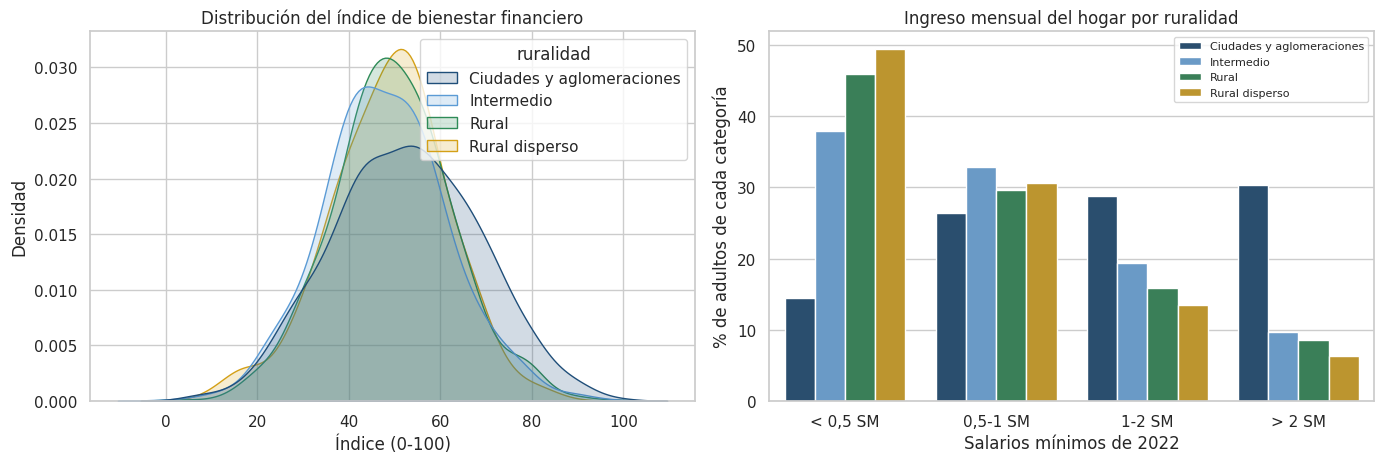

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.kdeplot(data=base, x='indice_bienestar', hue='ruralidad', hue_order=ORDEN_RURALIDAD, palette=COLORES_RURALIDAD,
            weights='peso', common_norm=False, fill=True, alpha=0.2, ax=axes[0])
axes[0].set_title('Distribución del índice de bienestar financiero')
axes[0].set_xlabel('Índice (0-100)')
axes[0].set_ylabel('Densidad')

dist_ingreso = (base.dropna(subset=['segmento_ingreso'])
                .groupby(['ruralidad', 'segmento_ingreso'], observed=True)['peso'].sum()
                .groupby(level=0, observed=True).transform(lambda s: s / s.sum() * 100)
                .rename('pct').reset_index())
sns.barplot(data=dist_ingreso, x='segmento_ingreso', y='pct', hue='ruralidad', hue_order=ORDEN_RURALIDAD,
            palette=COLORES_RURALIDAD, ax=axes[1])
axes[1].set_title('Ingreso mensual del hogar por ruralidad')
axes[1].set_xlabel('Salarios mínimos de 2022')
axes[1].set_ylabel('% de adultos de cada categoría')
axes[1].legend(title='', fontsize=8)
plt.tight_layout()
guardar('00_distribuciones')
plt.show()

**Qué muestra:** el ingreso está mucho más concentrado en los rangos bajos fuera de las ciudades: el ingreso promedio del hogar es de 1,82 salarios mínimos en ciudades y aglomeraciones, frente a 0,94 en intermedios, 0,86 en rurales y 0,76 en rurales dispersos. La distribución del índice de bienestar, en cambio, es muy parecida entre categorías (de 48,0 a 52,5 puntos en promedio).

**Qué significa:** la diferencia material entre territorios es grande, pero la percepción de bienestar financiero se parece mucho. Una posible explicación es que la percepción se forma comparándose con el entorno cercano (una de las frases del índice pregunta precisamente por la situación frente a los familiares). Esto anticipa que el índice captará poco de las diferencias entre territorios y justifica mirar también la resiliencia.

### 8.3 La brecha de acceso

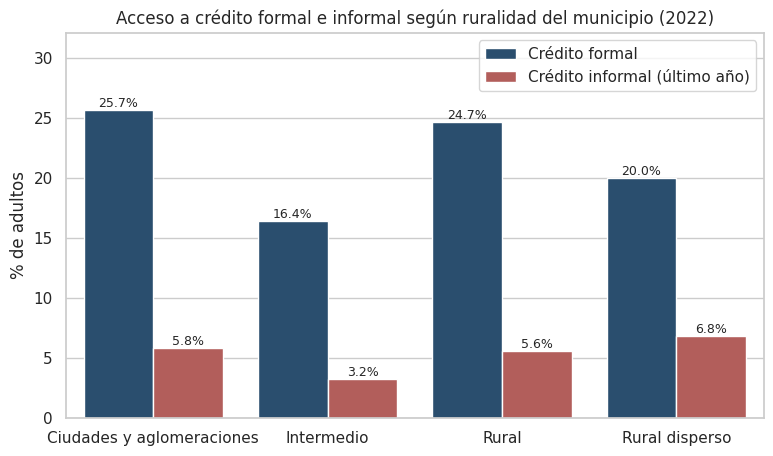

In [32]:
g1 = (resumen_ruralidad[['credito_formal', 'credito_informal']] * 100).reset_index(names='ruralidad')
g1 = g1.melt(id_vars='ruralidad', var_name='tipo', value_name='porcentaje')
g1['tipo'] = g1['tipo'].map({'credito_formal': 'Crédito formal', 'credito_informal': 'Crédito informal (último año)'})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=g1, x='ruralidad', y='porcentaje', hue='tipo', order=ORDEN_RURALIDAD, palette=['#1f4e79', '#c0504d'])
for barras in ax.containers:
    ax.bar_label(barras, fmt='%.1f%%', fontsize=9)
plt.title('Acceso a crédito formal e informal según ruralidad del municipio (2022)')
plt.xlabel('')
plt.ylabel('% de adultos')
plt.ylim(0, g1['porcentaje'].max() * 1.25)
plt.legend(title='', loc='upper right')
guardar('01_credito_por_ruralidad')
plt.show()

In [33]:
# Prueba chi-cuadrado: ¿el acceso al crédito formal es independiente de la ruralidad?
tabla_contingencia = pd.crosstab(base['ruralidad'], base['credito_formal'])
chi2, p_chi2, gl, _ = stats.chi2_contingency(tabla_contingencia)
print(f'Chi-cuadrado = {chi2:.1f}, grados de libertad = {gl}, p-valor = {p_chi2:.4f}')
print(f"Crédito formal en zona rural y rural dispersa: {promedio_ponderado(base[base['rural'] == 1], 'credito_formal'):.1%}")
print(f"Crédito formal en ciudades e intermedios: {promedio_ponderado(base[base['rural'] == 0], 'credito_formal'):.1%}")

Chi-cuadrado = 13.2, grados de libertad = 3, p-valor = 0.0042
Crédito formal en zona rural y rural dispersa: 22.9%
Crédito formal en ciudades e intermedios: 23.8%


**Qué muestra:** el 25,7 % de los adultos de ciudades y aglomeraciones tiene crédito formal, frente a 16,4 % en municipios intermedios, 24,7 % en rurales y 20,0 % en rurales dispersos. La prueba chi-cuadrado (p = 0,004) indica que el acceso sí depende de la ruralidad, pero **el patrón no es una escalera descendente**: la categoría más baja es la intermedia, y agregando rural y rural disperso el acceso (22,9 %) es casi igual al de ciudades e intermedios (23,8 %).

**Qué significa:** la brecha que muestra el Reporte de Inclusión Financiera (41,8 % en ciudades frente a 17,1 % en rural disperso, con datos administrativos de 2024) **no se reproduce** en la tenencia autodeclarada de 2022. Hay dos explicaciones posibles que no se excluyen: el RIF cuenta productos registrados por las entidades según el municipio de la oficina, mientras la encuesta pregunta a la persona; y la muestra rural de la encuesta sale de solo 20 municipios, así que su estimación depende de cuáles fueron seleccionados. El crédito informal es algo mayor en lo rural disperso (6,8 %), pero es bajo en todas las categorías.

**Implicación para la pregunta:** el problema rural no parece ser solo de acceso al crédito. Las siguientes gráficas buscan dónde está la diferencia.

### 8.4 ¿La brecha se explica solo por el ingreso?

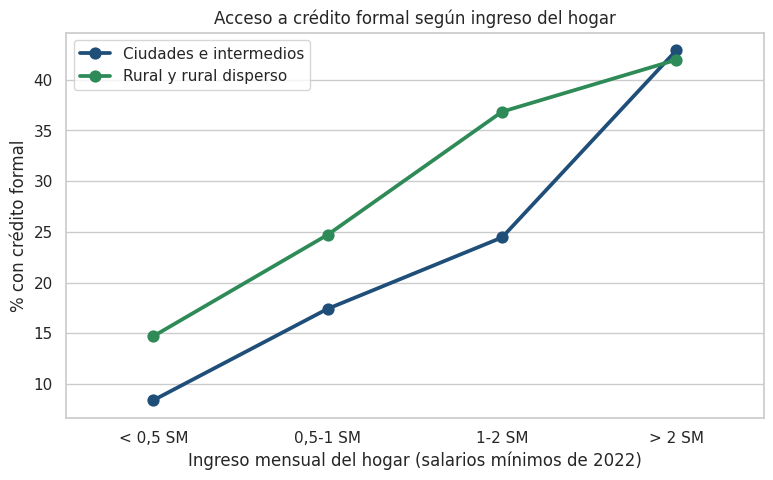

acceso                         \
area             Ciudades e intermedios Rural y rural disperso   
segmento_ingreso                                                 
< 0,5 SM                           8.40                  14.71   
0,5-1 SM                          17.42                  24.72   
1-2 SM                            24.45                  36.84   
> 2 SM                            42.90                  41.96   

                              encuestas                         
area             Ciudades e intermedios Rural y rural disperso  
segmento_ingreso                                                
< 0,5 SM                       1,037.00                 594.00  
0,5-1 SM                       1,252.00                 364.00  
1-2 SM                         1,050.00                 205.00  
> 2 SM                           717.00                  83.00

In [34]:
g2 = (base.dropna(subset=['segmento_ingreso'])
      .groupby(['segmento_ingreso', 'area'], observed=True)
      .apply(lambda g: pd.Series({'acceso': promedio_ponderado(g, 'credito_formal') * 100, 'encuestas': len(g)}))
      .reset_index())

plt.figure(figsize=(9, 5))
sns.pointplot(data=g2, x='segmento_ingreso', y='acceso', hue='area', palette=['#1f4e79', '#2e8b57'])
plt.title('Acceso a crédito formal según ingreso del hogar')
plt.xlabel('Ingreso mensual del hogar (salarios mínimos de 2022)')
plt.ylabel('% con crédito formal')
plt.legend(title='')
guardar('02_credito_por_ingreso')
plt.show()
g2.pivot_table(index='segmento_ingreso', columns='area', values=['acceso', 'encuestas'], observed=True)

**Qué muestra:** el acceso sube con el ingreso en las dos áreas, como predice la teoría (más capacidad de pago, menos riesgo para el prestamista). Pero **con el mismo ingreso, los adultos rurales tienen más crédito formal que los urbanos**: 14,7 % frente a 8,4 % entre quienes ganan menos de medio salario mínimo, y 36,8 % frente a 24,5 % entre uno y dos salarios. Solo por encima de dos salarios las líneas se juntan (42 % y 43 %), con apenas 83 encuestas rurales en ese grupo.

**Qué significa:** la ruralidad afecta el acceso **a través del ingreso**. Los hogares rurales ganan menos (0,86 salarios mínimos en promedio en municipios rurales frente a 1,82 en ciudades), y eso es lo que baja su acceso total; a igualdad de ingreso no hay desventaja rural. Una explicación consistente con los datos es la oferta especializada en lo rural: entre quienes pidieron crédito en zona rural, el 27,6 % acudió a cooperativas, frente al 16,2 % en ciudades e intermedios (sección 8.6).

**Hipótesis 2 (brecha condicional al ingreso): no se cumple.** Este es el hallazgo menos obvio del análisis.

### 8.5 Crédito formal y bienestar

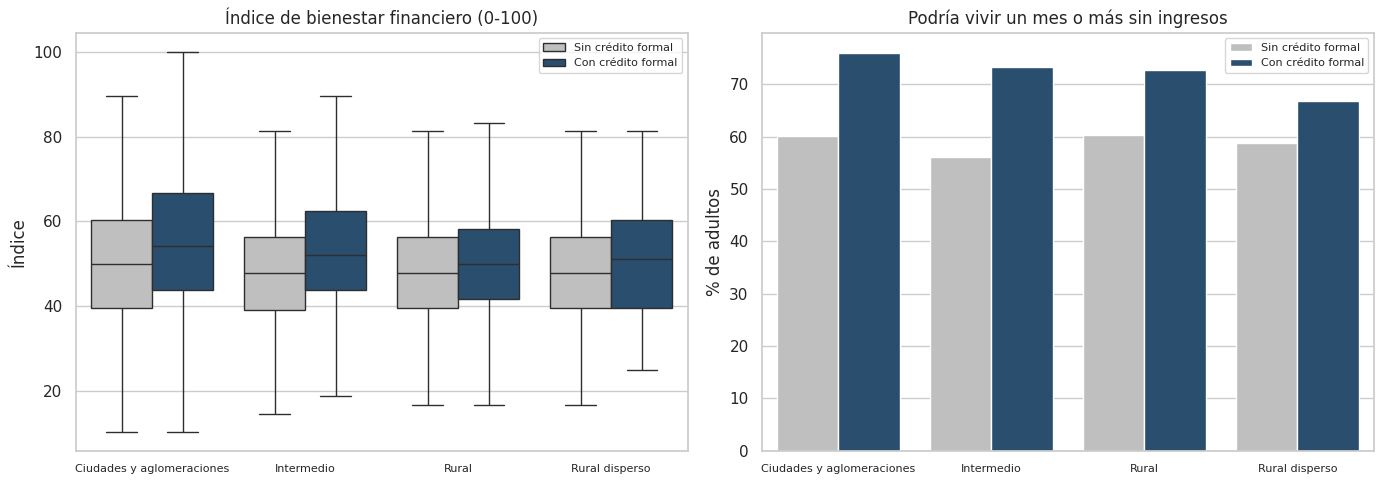

In [35]:
base['tiene_credito'] = base['credito_formal'].map({1: 'Con crédito formal', 0: 'Sin crédito formal'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=base, x='ruralidad', y='indice_bienestar', hue='tiene_credito', order=ORDEN_RURALIDAD,
            hue_order=['Sin crédito formal', 'Con crédito formal'], palette=['#bfbfbf', '#1f4e79'],
            showfliers=False, ax=axes[0])
axes[0].set_title('Índice de bienestar financiero (0-100)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Índice')
axes[0].legend(title='', fontsize=8)
axes[0].tick_params(axis='x', labelsize=8)

g3 = (base.groupby(['ruralidad', 'tiene_credito'], observed=True)
      .apply(lambda g: promedio_ponderado(g, 'aguanta_un_mes_o_mas') * 100).rename('pct').reset_index())
sns.barplot(data=g3, x='ruralidad', y='pct', hue='tiene_credito', order=ORDEN_RURALIDAD,
            hue_order=['Sin crédito formal', 'Con crédito formal'], palette=['#bfbfbf', '#1f4e79'], ax=axes[1])
axes[1].set_title('Podría vivir un mes o más sin ingresos')
axes[1].set_xlabel('')
axes[1].set_ylabel('% de adultos')
axes[1].legend(title='', fontsize=8)
axes[1].tick_params(axis='x', labelsize=8)
plt.tight_layout()
guardar('03_bienestar_por_credito')
plt.show()

**Diferencias de medias en la población rural (rural y rural disperso).** Se compara a quienes tienen y no tienen crédito formal. La prueba t de Welch dice si la diferencia es distinta de cero; no dice que el crédito la cause.

In [36]:
rural = base[base['rural'] == 1]
filas = []
for v in ['indice_bienestar', 'meses_resiliencia', 'ingreso_smmlv', 'gasto_hogar', 'ahorro_formal',
          'indice_activos', 'educ_superior', 'ocupado', 'trabaja_agro', 'ingreso_irregular']:
    con = rural.loc[rural['credito_formal'] == 1, v].dropna()
    sin = rural.loc[rural['credito_formal'] == 0, v].dropna()
    t, p = stats.ttest_ind(con, sin, equal_var=False)
    filas.append({'variable': v, 'con_credito': con.mean(), 'sin_credito': sin.mean(),
                  'diferencia': con.mean() - sin.mean(), 'p_valor': p,
                  'con_credito_ponderado': promedio_ponderado(rural[rural['credito_formal'] == 1], v),
                  'sin_credito_ponderado': promedio_ponderado(rural[rural['credito_formal'] == 0], v),
                  'n_con': len(con), 'n_sin': len(sin)})
diferencias_rural = pd.DataFrame(filas).set_index('variable')
diferencias_rural['diferencia_ponderada'] = diferencias_rural['con_credito_ponderado'] - diferencias_rural['sin_credito_ponderado']
diferencias_rural

,con_credito,sin_credito,diferencia,p_valor,con_credito_ponderado,sin_credito_ponderado,n_con,n_sin,diferencia_ponderada
variable,,,,,,,,,
indice_bienestar,51.28,48.33,2.95,0.00,49.45,49.04,304,985,0.40
meses_resiliencia,4.99,3.37,1.62,0.00,4.65,3.51,291,913,1.14
ingreso_smmlv,1.11,0.68,0.43,0.00,1.11,0.74,296,950,0.37
gasto_hogar,"870,401.34","620,062.37","250,338.97",0.00,"908,153.43","606,987.43",299,962,"301,166.00"
ahorro_formal,0.09,0.04,0.05,0.01,0.08,0.04,296,953,0.04
indice_activos,4.14,3.49,0.65,0.00,4.22,3.68,304,985,0.54
educ_superior,0.35,0.21,0.13,0.00,0.29,0.21,304,984,0.08
ocupado,0.58,0.44,0.15,0.00,0.59,0.45,304,985,0.14
trabaja_agro,0.12,0.10,0.02,0.36,0.15,0.10,304,985,0.05


In [37]:
# ¿La diferencia en bienestar se mantiene al comparar personas con el mismo nivel de ingreso?
bienestar_por_ingreso = rural.pivot_table(index='segmento_ingreso', columns='tiene_credito',
                                          values='indice_bienestar', aggfunc='mean', observed=True)
bienestar_por_ingreso['diferencia'] = bienestar_por_ingreso['Con crédito formal'] - bienestar_por_ingreso['Sin crédito formal']
bienestar_por_ingreso

tiene_credito,Con crédito formal,Sin crédito formal,diferencia
segmento_ingreso,,,
"< 0,5 SM",47.85,45.90,1.95
"0,5-1 SM",47.70,49.80,-2.09
1-2 SM,54.52,53.03,1.49
> 2 SM,60.80,56.09,4.71


**Qué muestra:** en la muestra rural, quienes tienen crédito formal reportan 2,95 puntos más de bienestar financiero (prueba t, p < 0,01) y aguantan más tiempo sin ingresos (5,0 frente a 3,4 meses). Pero **al ponderar con el factor de expansión la diferencia en el índice casi desaparece** (49,5 frente a 49,0). Además, dentro de cada segmento de ingreso las diferencias son pequeñas y cambian de signo (+2,0, −2,1, +1,5 y +4,7 puntos).

La diferencia que sí se sostiene es la de **resiliencia**: el 71 % de los rurales con crédito podría vivir un mes o más sin ingresos, frente al 60 % de los que no tienen.

**Qué significa:** quienes tienen crédito formal no son comparables con quienes no lo tienen. Con cifras ponderadas, ganan más (1,11 frente a 0,74 salarios mínimos), tienen más activos (4,2 frente a 3,7 bienes), más educación técnica o superior (29 % frente a 21 %), están más ocupados (59 % frente a 45 %) y tienen ingresos menos irregulares (36 % frente a 49 %). Todas esas diferencias son estadísticamente significativas en la prueba t. Es la evidencia directa del **problema de selección** que planteamos en la primera entrega: la mayor parte de la ventaja en bienestar se explica por las condiciones de partida.

**Hipótesis 3: se cumple.** Hay asociación positiva con la resiliencia, pero está mezclada con ingreso, activos y educación. El Modelo 2 de la siguiente entrega debe controlar por esas variables.

### 8.6 ¿Dónde está la fricción? Rechazo y tipo de entidad

Si el acceso total es parecido, la diferencia puede estar en qué pasa cuando alguien **pide** crédito y **a quién** se lo pide.

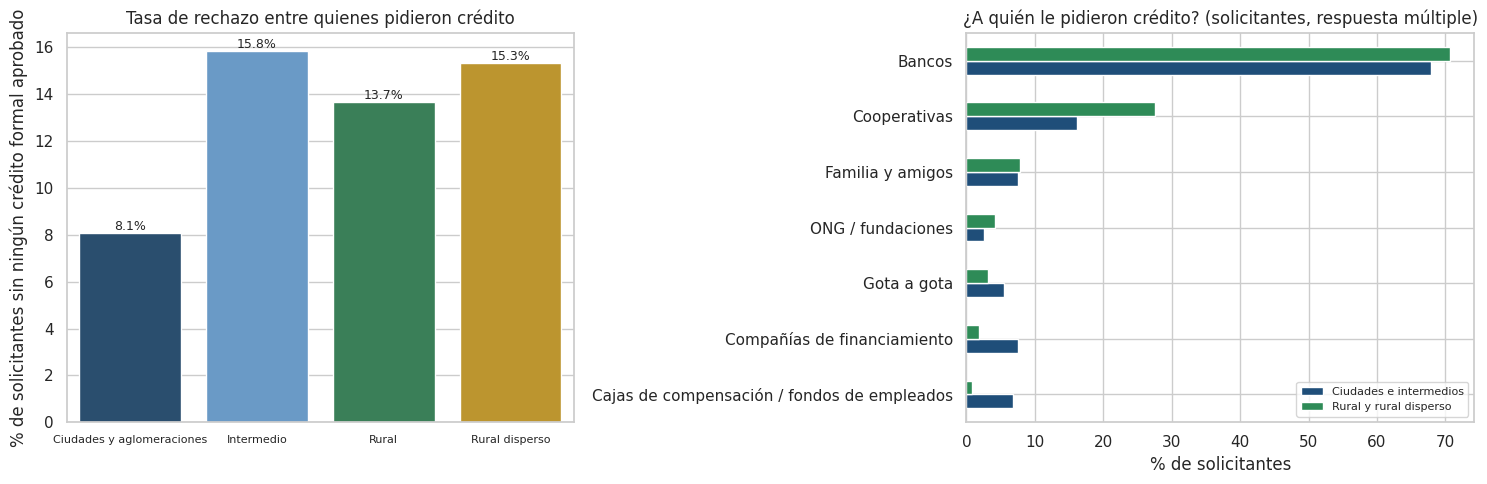

,tasa_rechazo,solicitantes
ruralidad,,
Ciudades y aglomeraciones,8.10,525.00
Intermedio,15.80,176.00
Rural,13.70,152.00
Rural disperso,15.30,80.00


,Ciudades e intermedios,Rural y rural disperso
Bancos,67.90,70.60
Cooperativas,16.20,27.60
ONG / fundaciones,2.50,4.20
Compañías de financiamiento,7.60,1.80
Cajas de compensación / fondos de empleados,6.80,0.90
Familia y amigos,7.50,7.80
Gota a gota,5.50,3.10


In [38]:
solicitantes = base[base['solicito_credito'] == 1]

# Tasa de rechazo: pidió en entidad formal y no le aprobaron ninguno, sobre el total que pidió
rechazo = solicitantes.groupby('ruralidad', observed=True).apply(
    lambda g: pd.Series({'tasa_rechazo': promedio_ponderado(g, 'credito_negado') * 100, 'solicitantes': len(g)}))

entidades = {'Bancos': 1, 'Cooperativas': 2, 'ONG / fundaciones': 3, 'Compañías de financiamiento': 5,
             'Cajas de compensación / fondos de empleados': 6, 'Familia y amigos': 7, 'Gota a gota': 11}
for nombre, i in entidades.items():
    solicitantes[nombre] = solicitantes[f'T303_{i}'].eq('Sí').astype(int)
entidades_por_area = pd.DataFrame({area: {n: promedio_ponderado(sub, n) * 100 for n in entidades}
                                   for area, sub in solicitantes.groupby('area', observed=True)})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=rechazo.index, y=rechazo['tasa_rechazo'], order=ORDEN_RURALIDAD,
            palette=[COLORES_RURALIDAD[r] for r in ORDEN_RURALIDAD], ax=axes[0])
for barras in axes[0].containers:
    axes[0].bar_label(barras, fmt='%.1f%%', fontsize=9)
axes[0].set_title('Tasa de rechazo entre quienes pidieron crédito')
axes[0].set_xlabel('')
axes[0].set_ylabel('% de solicitantes sin ningún crédito formal aprobado')
axes[0].tick_params(axis='x', labelsize=8)

entidades_por_area.sort_values('Rural y rural disperso').plot(kind='barh', color=['#1f4e79', '#2e8b57'], ax=axes[1])
axes[1].set_title('¿A quién le pidieron crédito? (solicitantes, respuesta múltiple)')
axes[1].set_xlabel('% de solicitantes')
axes[1].set_ylabel('')
axes[1].legend(title='', fontsize=8)
plt.tight_layout()
guardar('04_rechazo_y_entidades')
plt.show()
display(rechazo.round(1))
entidades_por_area.round(1)

**Qué muestra:** entre quienes pidieron crédito, al 8,1 % en ciudades y aglomeraciones no le aprobaron ninguno, frente a 13,7 % en municipios rurales, 15,3 % en rurales dispersos y 15,8 % en intermedios: **fuera de las ciudades el rechazo casi se duplica**. Los solicitantes rurales acuden más a cooperativas (27,6 % frente a 16,2 %) y a ONG (4,2 % frente a 2,5 %), y mucho menos a compañías de financiamiento y cajas o fondos de empleados, que dependen de un empleo formal.

**Qué significa:** esto es consistente con la teoría de **racionamiento de crédito** (Stiglitz y Weiss, 1981): cuando el prestamista no puede evaluar bien el riesgo, rechaza en vez de subir la tasa, y el riesgo es más difícil de evaluar con ingresos agropecuarios o irregulares y sin historial. Las cooperativas, que conocen mejor a sus asociados y a la comunidad, tienen ventaja de información en ese entorno, lo que ayuda a explicar por qué el acceso rural se sostiene a pesar del mayor rechazo.

**Limitación:** hay 232 solicitantes rurales, así que estas tasas tienen más incertidumbre que las del resto del análisis.

### 8.7 ¿Por qué la gente no pide crédito?

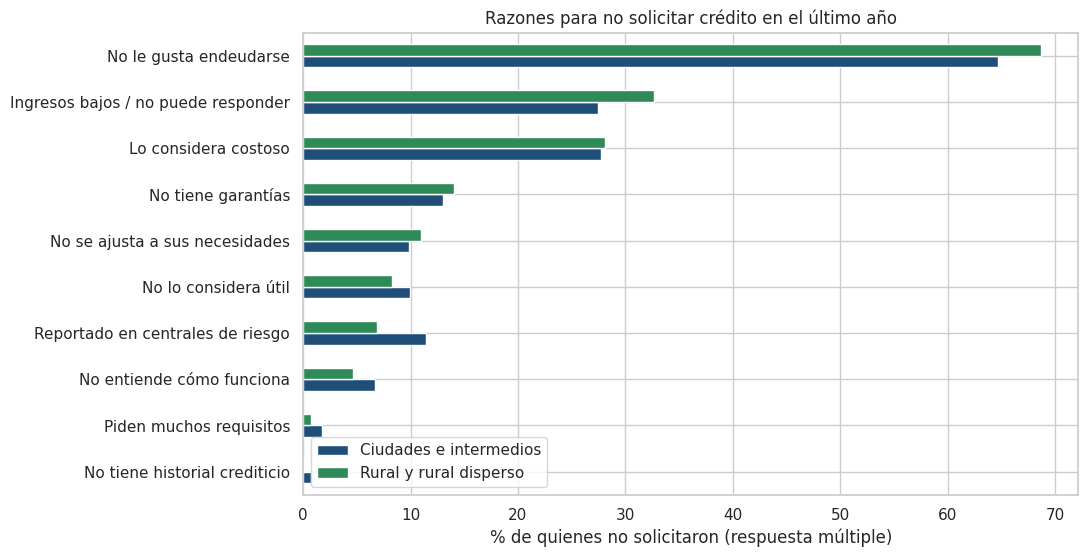

,Ciudades e intermedios,Rural y rural disperso
No tiene historial crediticio,0.70,0.10
Piden muchos requisitos,1.70,0.70
No entiende cómo funciona,6.70,4.60
Reportado en centrales de riesgo,11.40,6.90
No lo considera útil,10.00,8.30
No se ajusta a sus necesidades,9.90,10.90
No tiene garantías,13.00,14.00
Lo considera costoso,27.70,28.10
Ingresos bajos / no puede responder,27.40,32.70
No le gusta endeudarse,64.70,68.70


In [39]:
no_pidieron = base[base['solicito_credito'] == 0].copy()
no_pidieron = no_pidieron[no_pidieron['credito_formal'] == 0]    # quienes no tienen ni pidieron crédito
cols_barreras = [c for c in base.columns if c.startswith('barrera: ')]
g4 = pd.DataFrame({area: {c.replace('barrera: ', ''): promedio_ponderado(sub, c) * 100 for c in cols_barreras}
                   for area, sub in no_pidieron.groupby('area', observed=True)})
g4 = g4.sort_values('Rural y rural disperso')

g4.plot(kind='barh', figsize=(10, 6), color=['#1f4e79', '#2e8b57'])
plt.title('Razones para no solicitar crédito en el último año')
plt.xlabel('% de quienes no solicitaron (respuesta múltiple)')
plt.ylabel('')
plt.legend(title='')
guardar('05_barreras_credito')
plt.show()
g4.round(1)

**Qué muestra:** la razón dominante en las dos áreas es que **no les gusta endeudarse** (68,7 % en lo rural y 64,7 % en lo urbano). Le siguen los ingresos bajos (32,7 % frente a 27,4 %) y el costo (28 % en ambas). La falta de garantías pesa igual en las dos áreas (14 % y 13 %), y estar reportado en centrales de riesgo pesa menos en lo rural (6,9 % frente a 11,4 %).

**Qué significa:** la mayor parte de quienes no tienen crédito se **autoexcluyen** por razones de demanda: aversión a la deuda y falta de capacidad de pago. La barrera que más diferencia a lo rural es el ingreso, lo que coincide con la gráfica 8.4. Que las garantías no pesen más en lo rural indica que el racionamiento aparece en el rechazo a quien pide (8.6), no como una razón para no pedir. La aversión a la deuda también puede esconder "prestatarios desanimados", que no piden porque esperan ser rechazados; la encuesta no permite separar esos dos casos.

**Hipótesis 4 (las garantías pesan más en lo rural): no se cumple.** Pesa más el ingreso.

### 8.8 ¿Para qué se usa el crédito?

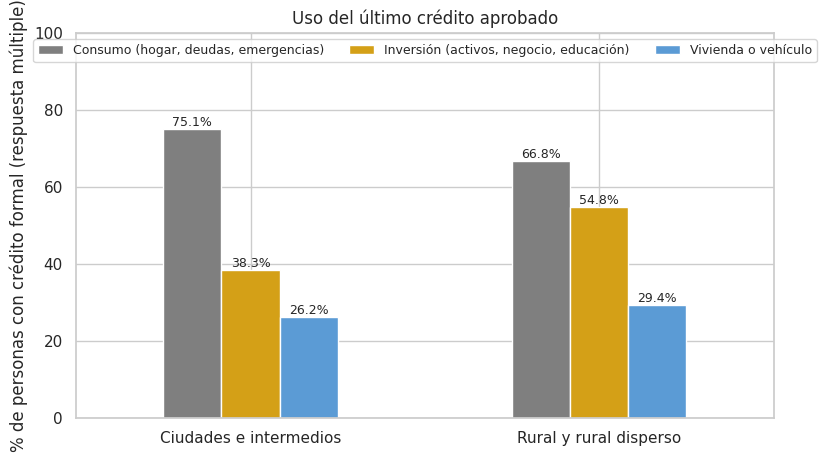

,"Consumo (hogar, deudas, emergencias)","Inversión (activos, negocio, educación)",Vivienda o vehículo
Ciudades e intermedios,75.10,38.30,26.20
Rural y rural disperso,66.80,54.80,29.40


In [40]:
con_credito = base[base['credito_formal'] == 1]
g5 = pd.DataFrame({area: {'Consumo (hogar, deudas, emergencias)': promedio_ponderado(sub, 'uso_consumo') * 100,
                          'Inversión (activos, negocio, educación)': promedio_ponderado(sub, 'uso_productivo') * 100,
                          'Vivienda o vehículo': promedio_ponderado(sub, 'uso_vivienda_vehiculo') * 100}
                   for area, sub in con_credito.groupby('area', observed=True)}).T

ax = g5.plot(kind='bar', figsize=(9, 5), color=['#7f7f7f', '#d4a017', '#5b9bd5'], rot=0)
for barras in ax.containers:
    ax.bar_label(barras, fmt='%.1f%%', fontsize=9)
plt.title('Uso del último crédito aprobado')
plt.ylabel('% de personas con crédito formal (respuesta múltiple)')
plt.xlabel('')
plt.ylim(0, 100)
plt.legend(title='', fontsize=9, loc='upper center', ncol=3)
guardar('06_uso_credito')
plt.show()
g5.round(1)

**Qué muestra:** el 54,8 % de los adultos rurales con crédito formal lo usó en inversión (activos, iniciar o sostener un negocio, educación), frente al 38,3 % en ciudades e intermedios. El uso en consumo (gastos del hogar, pagar otras deudas, emergencias) es alto en ambas áreas, pero menor en lo rural (66,8 % frente a 75,1 %).

**Qué significa:** en lo rural el crédito cumple más la función que plantea el mecanismo de la primera entrega: **relajar la restricción de liquidez para invertir**, por ejemplo en capital de trabajo agropecuario o en el negocio familiar. En lo urbano pesa más el financiamiento del consumo y el pago de otras deudas.

**Hipótesis 5 (en lo rural el crédito se usa más para consumo): no se cumple.** Se observa lo contrario.

### 8.9 Formas de ahorro

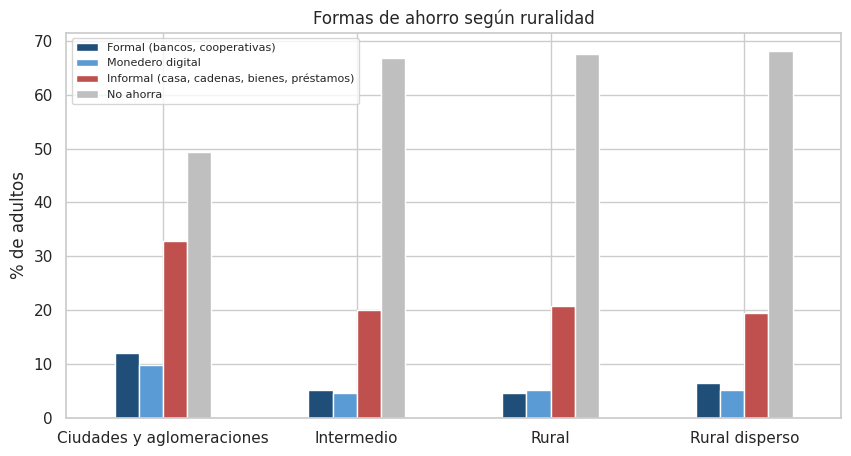

,"Formal (bancos, cooperativas)",Monedero digital,"Informal (casa, cadenas, bienes, préstamos)",No ahorra
Ciudades y aglomeraciones,12.00,9.90,32.80,49.30
Intermedio,5.20,4.60,20.00,66.80
Rural,4.60,5.20,20.70,67.50
Rural disperso,6.40,5.10,19.50,68.10


In [41]:
g6 = tabla_por_grupo(base, 'ruralidad', ['ahorro_formal', 'ahorro_digital', 'ahorro_informal', 'no_ahorra']).drop(columns='encuestas') * 100
g6.columns = ['Formal (bancos, cooperativas)', 'Monedero digital', 'Informal (casa, cadenas, bienes, préstamos)', 'No ahorra']

g6.plot(kind='bar', figsize=(10, 5), color=['#1f4e79', '#5b9bd5', '#c0504d', '#bfbfbf'], rot=0)
plt.title('Formas de ahorro según ruralidad')
plt.ylabel('% de adultos')
plt.xlabel('')
plt.legend(title='', fontsize=8)
guardar('07_ahorro_por_ruralidad')
plt.show()
g6.round(1)

**Qué muestra:** aquí sí aparece una brecha clara. En ciudades y aglomeraciones el 49,3 % de los adultos no ahorra, frente a cerca de 67 % a 68 % en municipios intermedios, rurales y rurales dispersos. El ahorro formal es de 12 % en ciudades y de 5 % a 6 % en el resto, y el ahorro informal (en la casa, en cadenas, prestando o comprando bienes) también es menor fuera de las ciudades.

**Qué significa:** la brecha rural en inclusión financiera es **más de ahorro que de crédito**. Con menos ingreso hay menos excedente para ahorrar, y el poco ahorro que hay se guarda por fuera del sistema. Esto importa para el bienestar porque el ahorro es el primer amortiguador ante un choque: un hogar que no ahorra depende del crédito, o de vender activos, para enfrentar una emergencia.

### 8.10 Correlaciones en la población rural

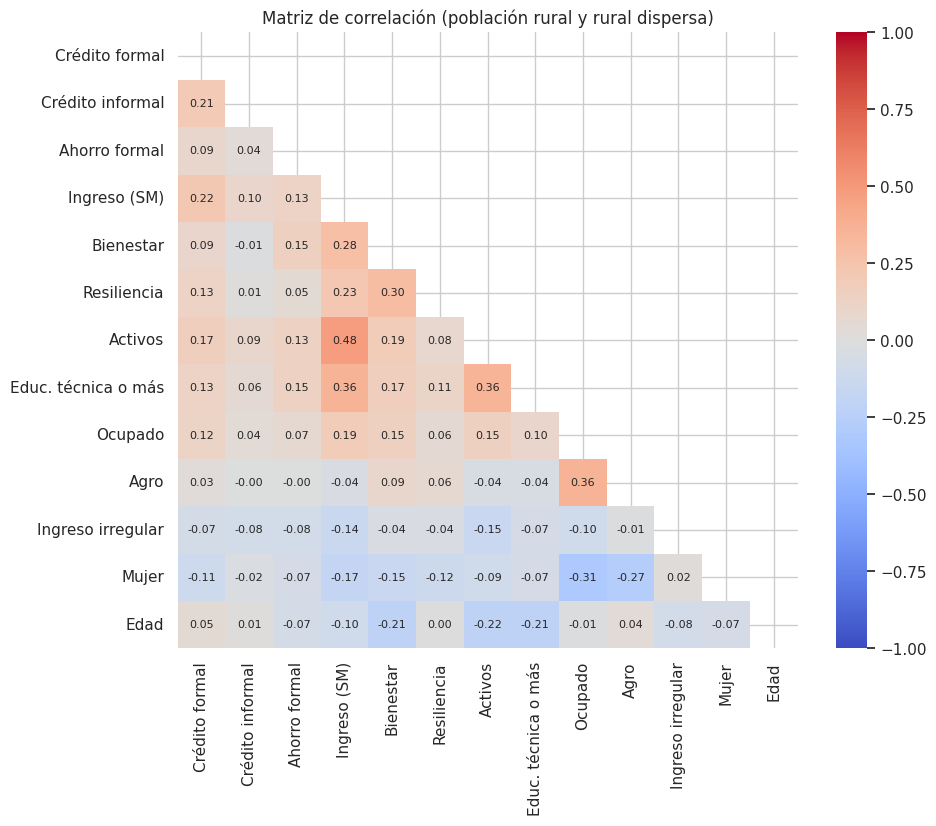

,Crédito formal
Mujer,-0.11
Ingreso irregular,-0.07
Agro,0.03
Edad,0.05
Ahorro formal,0.09
Bienestar,0.09
Ocupado,0.12
Resiliencia,0.13
Educ. técnica o más,0.13
Activos,0.17


In [42]:
nombres_corr = {'credito_formal': 'Crédito formal', 'credito_informal': 'Crédito informal', 'ahorro_formal': 'Ahorro formal',
                'ingreso_smmlv': 'Ingreso (SM)', 'indice_bienestar': 'Bienestar', 'meses_resiliencia': 'Resiliencia',
                'indice_activos': 'Activos', 'educ_superior': 'Educ. técnica o más', 'ocupado': 'Ocupado',
                'trabaja_agro': 'Agro', 'ingreso_irregular': 'Ingreso irregular', 'mujer': 'Mujer', 'edad': 'Edad'}
matriz_correlacion = rural[list(nombres_corr)].rename(columns=nombres_corr).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            mask=np.triu(np.ones_like(matriz_correlacion, dtype=bool)), annot_kws={'size': 8})
plt.title('Matriz de correlación (población rural y rural dispersa)')
guardar('08_correlaciones_rural')
plt.show()
matriz_correlacion['Crédito formal'].drop('Crédito formal').sort_values()

**Qué muestra:** en la población rural, el crédito formal se asocia sobre todo con el ingreso (0,22), con el crédito informal (0,21) y con los activos (0,17). Las correlaciones con educación, resiliencia y ocupación son menores (0,12 a 0,13), y la del bienestar es de solo 0,09. Ser mujer se asocia negativamente con tener crédito (−0,11).

**Qué significa:** la correlación positiva entre crédito formal e informal indica que **se complementan**: quien tiene crédito formal también recurre más al informal (11,8 % frente a 3,4 % de quien no tiene formal), lo que sugiere necesidades de financiación que el crédito formal no cubre por completo. Para el Modelo 1, ingreso, activos y educación son candidatos naturales; como están correlacionados entre sí, hay que vigilar la multicolinealidad.

### 8.11 Acceso al crédito por departamento

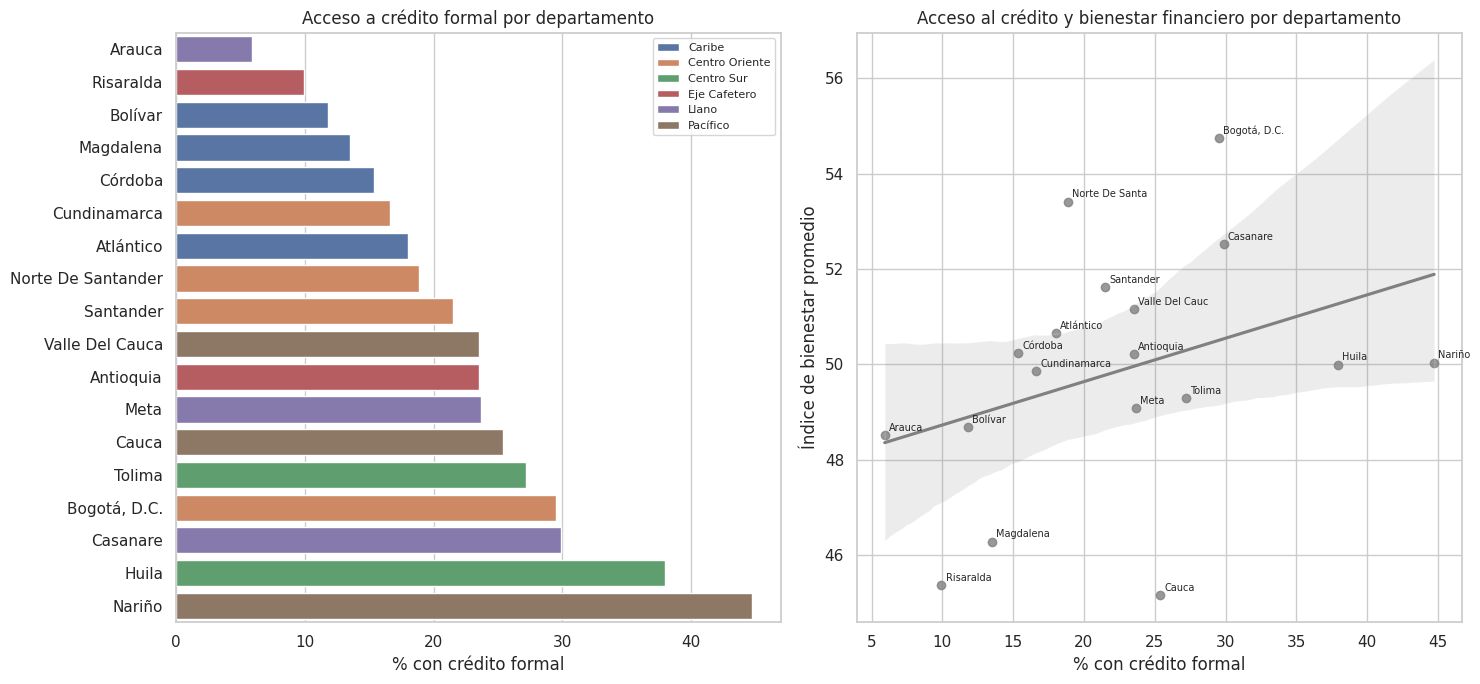

,departamento,region,acceso,pct_rural,bienestar,encuestas
1,Arauca,Llano,5.90,0.00,48.50,104.00
18,Risaralda,Eje Cafetero,9.90,100.00,45.40,50.00
5,Bolívar,Caribe,11.80,32.80,48.70,183.00
14,Magdalena,Caribe,13.50,18.50,46.30,292.00
12,Córdoba,Caribe,15.40,100.00,50.20,85.00
11,Cundinamarca,Centro Oriente,16.60,0.00,49.90,181.00
2,Atlántico,Caribe,18.00,0.00,50.70,582.00
17,Norte De Santander,Centro Oriente,18.90,100.00,53.40,71.00
19,Santander,Centro Oriente,21.50,48.50,51.60,343.00
21,Valle Del Cauca,Pacífico,23.50,13.40,51.20,611.00


In [43]:
g8 = (base.groupby(['departamento', 'region'], observed=True)
      .apply(lambda g: pd.Series({'acceso': promedio_ponderado(g, 'credito_formal') * 100,
                                  'pct_rural': promedio_ponderado(g, 'rural') * 100,
                                  'bienestar': promedio_ponderado(g, 'indice_bienestar'),
                                  'encuestas': len(g)}))
      .reset_index())
g8 = g8[g8['encuestas'] >= 30].sort_values('acceso')   # con menos de 30 encuestas el porcentaje no es confiable
g8['departamento'] = g8['departamento'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.barplot(data=g8, y='departamento', x='acceso', hue='region', dodge=False, order=g8['departamento'], ax=axes[0])
axes[0].set_title('Acceso a crédito formal por departamento')
axes[0].set_xlabel('% con crédito formal')
axes[0].set_ylabel('')
axes[0].legend(title='', fontsize=8, loc='upper right')

sns.regplot(data=g8, x='acceso', y='bienestar', ax=axes[1], color='gray')
for _, fila in g8.iterrows():
    axes[1].annotate(fila['departamento'][:14], (fila['acceso'], fila['bienestar']), fontsize=7,
                     xytext=(3, 3), textcoords='offset points')
axes[1].set_title('Acceso al crédito y bienestar financiero por departamento')
axes[1].set_xlabel('% con crédito formal')
axes[1].set_ylabel('Índice de bienestar promedio')
plt.tight_layout()
guardar('09_departamentos')
plt.show()
g8.round(1)

**Qué muestra:** el acceso va de 5,9 % en Arauca a 44,7 % en Nariño entre los 18 departamentos con 30 o más encuestas. Los tres con más acceso (Nariño, Huila y Casanare) fueron encuestados solo en municipios rurales. Entre departamentos, más acceso al crédito se asocia con algo más de bienestar financiero promedio.

**Cuidado al leerla:** en esta encuesta cada departamento fue muestreado casi siempre en municipios de una sola categoría de ruralidad, así que el dato de un departamento refleja a los municipios seleccionados y no a todo el departamento. La gráfica sirve para ver la **heterogeneidad territorial** y como primer insumo del mapa de vulnerabilidad, no para ordenar departamentos.

### 8.12 Resumen: qué dicen los datos sobre las hipótesis

| Hipótesis | Resultado | Evidencia |
|---|---|---|
| 1. El acceso al crédito formal es menor en lo rural | **Parcial** | Hay diferencias significativas (p = 0,004), pero el mínimo está en municipios intermedios (16,4 %); rural 24,7 % y ciudades 25,7 % |
| 2. Con el mismo ingreso, lo rural sigue teniendo menos acceso | **No se cumple** | A igual ingreso el acceso rural es mayor o igual; la ruralidad opera a través del ingreso |
| 3. Quien tiene crédito tiene mejor bienestar, pero no es comparable | **Se cumple** | Más resiliencia (71 % frente a 60 %), pero también más ingreso, activos, educación y empleo; el índice ponderado casi no cambia |
| 4. En lo rural pesan más las garantías | **No se cumple** | Pesan más los ingresos bajos; la fricción de oferta aparece como mayor rechazo (14 % a 16 % frente a 8 %) |
| 5. En lo rural el crédito se usa más para consumo | **No se cumple** | Se usa más para invertir (55 % frente a 38 %) |

**Hallazgo adicional:** la brecha más clara entre ciudades y el resto no es de crédito sino de **ahorro** (49 % frente a 67 %–68 % no ahorra).

**Hipótesis para la siguiente entrega:** el acceso rural al crédito formal depende sobre todo del ingreso y de los activos, y su asociación con el bienestar pasa por la **resiliencia ante choques** más que por el nivel de bienestar percibido. El Modelo 1 debe incluir ingreso, activos, educación, ocupación y ruralidad; el Modelo 2 debe usar la resiliencia como resultado principal y controlar por esas mismas variables.

---
## 9. Exportación de resultados

In [44]:
columnas_finales = ['cod_mpio', 'municipio', 'cod_dpto', 'departamento', 'region', 'ruralidad', 'rural', 'area', 'peso',
                    'credito_formal', 'credito_informal', 'solicito_credito', 'credito_negado', 'gota_a_gota',
                    'uso_consumo', 'uso_productivo', 'uso_vivienda_vehiculo',
                    'ahorro_formal', 'ahorro_digital', 'ahorro_informal', 'no_ahorra',
                    'ingreso_rango', 'ingreso_hogar', 'ingreso_smmlv', 'log_ingreso', 'segmento_ingreso', 'gasto_hogar',
                    'gasta_mas_que_gana', 'indice_bienestar', 'meses_resiliencia', 'aguanta_un_mes_o_mas',
                    'indice_activos', 'sexo', 'mujer', 'edad', 'jefe_hogar', 'educacion', 'educ_superior',
                    'actividad', 'ocupado', 'cuenta_propia', 'trabaja_agro', 'ingreso_irregular', 'estrato',
                    'menores_hogar', 'ocupados_hogar', 'ocupados_estables', 'usa_internet', 'cocina_con_lena'] + \
                   [c for c in base.columns if c.startswith('barrera: ')]
base[columnas_finales].to_csv('data/processed/base_inclusion_financiera_2022.csv', index=False, encoding='utf-8-sig')

with pd.ExcelWriter('outputs/tables/tablas_eda.xlsx') as writer:
    descriptivas.to_excel(writer, sheet_name='Descriptivas')
    resumen_ruralidad.to_excel(writer, sheet_name='Resumen ruralidad')
    g2.to_excel(writer, sheet_name='Credito por ingreso', index=False)
    diferencias_rural.to_excel(writer, sheet_name='Diferencias rural')
    bienestar_por_ingreso.to_excel(writer, sheet_name='Bienestar por ingreso')
    rechazo.to_excel(writer, sheet_name='Rechazo')
    entidades_por_area.to_excel(writer, sheet_name='Entidades')
    g4.to_excel(writer, sheet_name='Barreras')
    g5.to_excel(writer, sheet_name='Uso del credito')
    g6.to_excel(writer, sheet_name='Ahorro')
    matriz_correlacion.to_excel(writer, sheet_name='Correlaciones')
    g8.to_excel(writer, sheet_name='Departamentos', index=False)
    tabla_atipicos.to_excel(writer, sheet_name='Atipicos')
    faltantes.to_frame('pct_faltante').to_excel(writer, sheet_name='Faltantes')

print('Base procesada:', base[columnas_finales].shape)

Base procesada: (5532, 59)


In [45]:
# requirements.txt con las versiones exactas de este entorno
from importlib.metadata import version
librerias = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'openpyxl', 'requests']
with open('requirements.txt', 'w') as f:
    for lib in librerias:
        f.write(f'{lib}=={version(lib)}\n')
print(open('requirements.txt').read())

pandas==2.2.3
numpy==2.1.3
matplotlib==3.10.0
seaborn==0.13.2
scipy==1.16.3
openpyxl==3.1.5
requests==2.32.4



In [46]:
# Descargar los resultados para subirlos al repositorio (solo en Colab)
import shutil
shutil.make_archive('outputs', 'zip', '.', 'outputs')
shutil.make_archive('data', 'zip', '.', 'data')
try:
    from google.colab import files
    for archivo in ['outputs.zip', 'data.zip', 'requirements.txt']:
        files.download(archivo)
except ImportError:
    print('Fuera de Colab: los archivos quedaron en la carpeta de trabajo.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>